# Moodle survey analysis

In [1]:
# import dependencies
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

## Aggregated numbers

In [2]:
# import courseID - courseName - courseCategory for looping
base_table_path = "C:/Users/ywa/Documents/Data/Moodle Query/Feb2026/KIC-course completion rate.csv"
base_df = pd.read_csv(base_table_path, sep = ';')

base_df.columns = ['courseID', 'Course', 'Course Category']
print(base_df.info())
base_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   courseID         94 non-null     int64 
 1   Course           94 non-null     object
 2   Course Category  94 non-null     object
dtypes: int64(1), object(2)
memory usage: 2.3+ KB
None


,courseID,Course,Course Category
0,106,Einführung in die KI,Über KI
1,58,AICE your exams – Generative KI als Copilot im...,Studieren
2,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI
3,313,EU AI Act Essentials,Studieren
4,197,KIÖV - KI in öffentlichen Verwaltungen,Studieren


### Import data

In [3]:
# import pre and post surveys --> stack rows together

agg_pre_list = []
agg_post_list = []

pre_DE = "Umfrage_zu_Kursbeginn.csv"
pre_EN = "Start_of_course_Questionnaire.csv"

post_DE = "Umfrage_zum_Kursende.csv"
post_EN = "End_of_course_Questionnaire.csv"

survey_base_path = "C:/Users/ywa/Documents/Data/Moodle User-Survey/Feb_26"

for courseID in base_df['courseID']:
    #pre survey
    file_path_pre_de = os.path.join(survey_base_path, str(courseID), pre_DE)
    file_path_pre_en = os.path.join(survey_base_path, str(courseID), pre_EN)
    
    pre_path = file_path_pre_de if os.path.exists(file_path_pre_de) else (file_path_pre_en if os.path.exists(file_path_pre_en) else None)
    
    if pre_path is None:
        print(f"Warning: Pre survey file not found for courseID = {courseID}")
    else:
        try:
            pre_survey_df = pd.read_csv(pre_path, sep = ',')
            pre_survey_df['courseID'] = courseID
            
            agg_pre_list.append(pre_survey_df)
            
        except Exception as e:
            print(f"Warning: Failed reading {pre_path} for courseID = {courseID}:{e}")
            
    # post survey
    file_path_post_de = os.path.join(survey_base_path, str(courseID), post_DE)
    file_path_post_en = os.path.join(survey_base_path, str(courseID), post_EN)
    
    post_path = file_path_post_de if os.path.exists(file_path_post_de) else (file_path_post_en if os.path.exists(file_path_post_en) else None)
    
    if post_path is None:
        print(f"Warning: Post survey file not found for courseID = {courseID}")
    else:
        try:
            post_survey_df = pd.read_csv(post_path, sep = ',')
            post_survey_df['courseID'] = courseID
            
            agg_post_list.append(post_survey_df)
        
        except Exception as e:
            print(f"Warning: Falid reading {post_path} for courseID = {courseID} : {e}")

agg_pre_df = pd.concat(agg_pre_list, ignore_index = True) if agg_pre_list else pd.DataFrame()
agg_post_df = pd.concat(agg_post_list, ignore_index = True) if agg_post_list else pd.DataFrame()
    

In [4]:
print(agg_pre_df.shape)
print(agg_post_df.shape)

# drop unnecessary columns
agg_pre_df = agg_pre_df.drop(['Response', 'Submitted on:', 'Institution', 'Department', 'Group', 'ID', 'Full name', 'Username'], axis = 1)
agg_post_df = agg_post_df.drop(['Response', 'Submitted on:', 'Institution', 'Department', 'Group', 'ID', 'Full name', 'Username'], axis = 1)

# drop unnecessary columns
agg_pre_df = agg_pre_df.drop(['Antworten', 'Abgegeben:', 'Abteilung', 'Gruppe', 'Nutzer-ID', 'Vollständiger Name', 'Anmeldename'], axis = 1)
agg_post_df = agg_post_df.drop(['Antworten', 'Abgegeben:', 'Abteilung', 'Gruppe', 'Nutzer-ID', 'Vollständiger Name', 'Anmeldename'], axis = 1)


(19750, 148)
(11101, 209)


In [5]:
print(agg_pre_df.info())
print(agg_pre_df.shape)
print(agg_pre_df.isnull().sum().shape)

print(agg_post_df.info())
print(agg_post_df.shape)
print(agg_post_df.isnull().sum().shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19750 entries, 0 to 19749
Columns: 133 entries, Course to Q06_Question 6->I’d rather not answer
dtypes: float64(129), int64(1), object(3)
memory usage: 20.0+ MB
None
(19750, 133)
(133,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11101 entries, 0 to 11100
Columns: 194 entries, Course to Q09_Anregungen
dtypes: float64(187), int64(1), object(6)
memory usage: 16.4+ MB
None
(11101, 194)
(194,)


In [6]:
print(len(pd.unique(agg_pre_df.columns)))
print(len(pd.unique(agg_post_df.columns)))

133
194


### Preprocessing

In [7]:
# list cols for standarisation

pre_en_cols = ['Course', \
               'Q01_Question 1->I’m interested in the course topic.', \
               'Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).', \
               'Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).', \
               'Q01_Question 1->I want to deepen my knowledge for professional development.', \
               'Q01_Question 1->I’m pursuing a higher professional qualification or career change.', \
               'Q01_Question 1->I already have prior knowledge and am looking to refresh or expand it.', \
               'Q01_Question 1->I want to use the course materials in my own teaching.', \
               'Q01_Question 1->Other', 'Q02_Question 2->Foundations of AI', \
               'Q02_Question 2->Machine Learning', \
               'Q02_Question 2->Natural Language Processing / Large Language Models (NLP / LLMs)', \
               'Q02_Question 2->Data Science', 'Q02_Question 2->Data Literacy', \
               'Q02_Question 2->Robotics', \
               'Q02_Question 2->Human-AI Interaction (e.g. Human-Computer Interaction)', \
               'Q02_Question 2->Internet of Things (IoT) & Industry 4.0', \
               'Q02_Question 2->Other', 'Q03_Question 3->AI in Healthcare', \
               'Q03_Question 3->AI in Education', \
               'Q03_Question 3->AI in Public Administration', \
               'Q03_Question 3->AI for Business & Management', \
               'Q03_Question 3->Ethical and Societal Questions Related to AI', \
               'Q03_Question 3->Other', 'Q04_Question 4->Male', 'Q04_Question 4->Female', 'Q04_Question 4->Diverse', \
               'Q04_Question 4->I’d rather not answer', \
               'Q05_Question 5->Doctorate / PhD', \
               'Q05_Question 5->Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
               'Q05_Question 5->Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
               'Q05_Question 5->Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
               'Q05_Question 5->Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
               'Q05_Question 5->Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
               'Q05_Question 5->No formal school-leaving certificate or training', \
               'Q05_Question 5->I’d rather not answer', \
               'Q06_Question 6->Manufacturing, Construction, or Engineering', \
               'Q06_Question 6->Trade, Transport, or Logistics', \
               'Q06_Question 6->Information Technology or Media', \
               'Q06_Question 6->Finance, Insurance, or Real Estate', \
               'Q06_Question 6->Healthcare or Social Services', \
               'Q06_Question 6->Education, Research, or Childcare', \
               'Q06_Question 6->Public Administration or Government', \
               'Q06_Question 6->Hospitality or Tourism', \
               'Q06_Question 6->Other Services', \
               'Q06_Question 6->Other / None of the above', \
               'Q06_Question 6->I’d rather not answer']

post_en_cols = ['Course', \
                'Q01_Question 1->Very good', \
                'Q01_Question 1->Good', 'Q01_Question 1->Average', \
                'Q01_Question 1->Bad', 'Q01_Question 1->Very bad', \
                'Q02_Question 2->Yes', 'Q02_Question 2->No', \
                'Q03_Question 3->The content was not accurate or up-to-date', \
                'Q03_Question 3->The explanations or structure were hard to follow (didactics)', \
                'Q03_Question 3->The course design or layout made it difficult to navigate', \
                'Q03_Question 3->The level of the course did not match my expectations', \
                'Q03_Question 3->The course did not meet my learning goals', \
                'Q03_Question 3->The technical quality (videos, platform, interactions) was poor', \
                'Q03_Question 3->Other', 'Q04_Question 4->Completely', \
                'Q04_Question 4->Mostly', 'Q04_Question 4->Partly', \
                'Q04_Question 4->Not really', 'Q04_Question 4->Not at all', \
                'Q05_Question 5->Extensive', 'Q05_Question 5->Somewhat extensive', \
                'Q05_Question 5->Average', 'Q05_Question 5->Somewhat limited', \
                'Q05_Question 5->Limited', 'Q06_Question 6->Extensive', \
                'Q06_Question 6->Somewhat extensive', 'Q06_Question 6->Average', \
                'Q06_Question 6->Somewhat limited', 'Q06_Question 6->Limited', \
                'Q07_Question 7->Short videos or video lectures', \
                'Q07_Question 7->Written explanations or reading materials', \
                'Q07_Question 7->Practice exercises (e.g. programming tasks, quizzes)', \
                'Q07_Question 7->Visual aids (e.g. diagrams, infographics, simulations)', \
                'Q07_Question 7->Final test or exam', \
                'Q07_Question 7->Peer discussion or forum participation', \
                'Q07_Question 7->AI Chatbot (KI-Lernassistent)', \
                'Q07_Question 7->Other', 'Q08_Question 8->Very helpful', \
                'Q08_Question 8->Helpful', 'Q08_Question 8->Neutral', \
                'Q08_Question 8->Not very helpful', \
                'Q08_Question 8->Not helpful at all', \
                'Q08_Question 8->I haven’t used it', \
                'Q09_Question 9->To get explanations of specific concepts', \
                'Q09_Question 9->To summarise course content (e.g. texts, videos, exercises)', \
                'Q09_Question 9->To get content recommendations or navigation help', \
                'Q09_Question 9->To prepare for quizzes or the final test', \
                'Q09_Question 9->To help with programming tasks or exercises', \
                'Q09_Question 9->To ask administrative or organisational questions', \
                'Q09_Question 9->I tried it out, but didn’t use it seriously', \
                'Q09_Question 9->I didn’t use the chatbot', \
                'Q09_Question 9->Other (please specify)', 'Q10_Question 10->Female', \
                'Q10_Question 10->Male', 'Q10_Question 10->Other', \
                'Q10_Question 10->I’d rather not answer', \
                'Q11_Question 11->Doctorate / PhD', \
                'Q11_Question 11->Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
                'Q11_Question 11->Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
                'Q11_Question 11->Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
                'Q11_Question 11->Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
                'Q11_Question 11->Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
                'Q11_Question 11->No formal school-leaving certificate or training', \
                'Q11_Question 11->I’d rather not answer', \
                'Q12_Question 12->Manufacturing, Construction, or Engineering', \
                'Q12_Question 12->Trade, Transport, or Logistics', \
                'Q12_Question 12->Information Technology or Media', \
                'Q12_Question 12->Finance, Insurance, or Real Estate', \
                'Q12_Question 12->Healthcare or Social Services', \
                'Q12_Question 12->Education, Research, or Childcare', \
                'Q12_Question 12->Public Administration or Government', \
                'Q12_Question 12->Hospitality or Tourism', \
                'Q12_Question 12->Other Services', \
                'Q12_Question 12->Other / None of the above', \
                'Q12_Question 12->I’d rather not answer']

pre_de_cols = ['Course', \
               'Q01_Question 1->Ich interessiere mich für das Kursthema.', \
               'Q01_Question 1->Ich möchte ein Zertifikat erhalten (zB. Teilnahmebestätigung, Leistungsnachweis).', \
               'Q01_Question 1->Es ist Teil meines Universitätsstudiums (z. B. ein Pflicht- oder Wahlfach).', \
               'Q01_Question 1->Ich möchte mein Wissen zur beruflichen Weiterentwicklung vertiefen.', \
               'Q01_Question 1->Ich strebe eine berufliche Höherqualifizierung oder einen Berufswechsel an.', \
               'Q01_Question 1->Ich verfüge bereits über Vorkenntnisse und möchte diese auffrischen oder erweitern.', \
               'Q01_Question 1->Ich möchte die Kursmaterialien in meinem eigenen Unterricht verwenden.', \
               'Q01_Question 1->Sonstiges', 'Q02_Question 2->Grundlagen der KI', \
               'Q02_Question 2->Maschinelles Lernen', \
               'Q02_Question 2->Natural Language Processing / Large Language Models (NLP / LL.M.)', \
               'Q02_Question 2->Data Science', 'Q02_Question 2->Datenkompetenz', \
               'Q02_Question 2->Robotik', \
               'Q02_Question 2->Mensch-KI-Interaktion (z. B. Mensch-Computer-Interaktion)', \
               'Q02_Question 2->Internet der Dinge (IoT) & Industrie 4.0', \
               'Q02_Question 2->Sonstiges', 'Q03_Question 3->KI im Gesundheitswesen', \
               'Q03_Question 3->KI im Bildungswesen', \
               'Q03_Question 3->KI in der öffentlichen Verwaltung', \
               'Q03_Question 3->KI für Wirtschaft und Management', \
               'Q03_Question 3->Ethische und gesellschaftliche Fragen im Zusammenhang mit KI', \
               'Q03_Question 3->Sonstiges', 'Q04_Question 4->Männlich', \
               'Q04_Question 4->Weiblich', 'Q04_Question 4->Divers', \
               'Q04_Question 4->Ich möchte diese Frage nicht beantworten', \
               'Q05_Question 5->Promotion', \
               'Q05_Question 5->Masterabschluss oder gleichwertiger Abschluss (z. B. Diplom, Magister, postgradualer Hochschulabschluss)', \
               'Q05_Question 5->Bachelorabschluss oder gleichwertiger Abschluss (z. B. B.Sc., B.A., Fachhochschulabschluss)', \
               'Q05_Question 5->Abgeschlossene Berufsausbildung (z. B. Lehre, Handelsschule, Fachoberschule)', \
               'Q05_Question 5->Abitur (z. B. Abitur, Mittlere Reife, GCSE)', \
               'Q05_Question 5->Hauptschulabschluss (z. B. Realschule, Hauptschule)', \
               'Q05_Question 5->Kein Schulabschluss oder Ausbildung', \
               'Q05_Question 5->Ich möchte diese Frage nicht beantworten', \
               'Q06_Question 6->Fertigung, Bauwesen oder Ingenieurwesen', \
               'Q06_Question 6->Handel, Transport oder Logistik', \
               'Q06_Question 6->Informationstechnologie oder Medien', \
               'Q06_Question 6->Finanzen, Versicherungen oder Immobilien', \
               'Q06_Question 6->Gesundheits- oder Sozialwesen', \
               'Q06_Question 6->Bildung, Forschung oder Kinderbetreuung', \
               'Q06_Question 6->Öffentliche Verwaltung oder Regierung', \
               'Q06_Question 6->Gastgewerbe oder Tourismus', \
               'Q06_Question 6->Sonstige Dienstleistungen', \
               'Q06_Question 6->Sonstige / Keine der oben genannten', \
               'Q06_Question 6->Ich möchte lieber nicht antworten']

post_de_cols = ['Course', \
                'Q01_Question 1->Sehr gut', \
                'Q01_Question 1->Gut', 'Q01_Question 1->Durchschnittlich', \
                'Q01_Question 1->Schlecht', 'Q01_Question 1->Sehr schlecht', \
                'Q02_Question 2->Ja', 'Q02_Question 2->Nein', \
                'Q03_Question 3->Die Inhalte waren nicht korrekt oder aktuell.', \
                'Q03_Question 3->Die Erklärungen oder die Struktur waren schwer verständlich (Didaktik).', \
                'Q03_Question 3->Das Kursdesign oder -layout erschwerte die Navigation.', \
                'Q03_Question 3->Das Kursniveau entsprach nicht meinen Erwartungen.', \
                'Q03_Question 3->Der Kurs entsprach nicht meinen Lernzielen.', \
                'Q03_Question 3->Die technische Qualität (Videos, Plattform, Interaktionen) war mangelhaft.', \
                'Q03_Question 3->Sonstiges', 'Q04_Question 4->Vollständig', \
                'Q04_Question 4->Größtenteils', 'Q04_Question 4->Teilweise', \
                'Q04_Question 4->Nicht wirklich', 'Q04_Question 4->Überhaupt nicht', \
                'Q05_Question 5->Umfangreich', 'Q05_Question 5->Etwas umfangreich', \
                'Q05_Question 5->Durchschnittlich', \
                'Q05_Question 5->Etwas eingeschränkt', 'Q05_Question 5->Eingeschränkt', \
                'Q06_Question 6->Umfangreich', 'Q06_Question 6->Etwas umfangreich', \
                'Q06_Question 6->Durchschnittlich', \
                'Q06_Question 6->Etwas eingeschränkt', 'Q06_Question 6->Eingeschränkt', \
                'Q07_Question 7->Kurze Videos oder Videovorträge', \
                'Q07_Question 7->Schriftliche Erklärungen oder Lesematerial', \
                'Q07_Question 7->Übungen (z. B. Programmieraufgaben, Quizze)', \
                'Q07_Question 7->Visuelle Hilfsmittel (z. B. Diagramme, Infografiken, Simulationen)', \
                'Q07_Question 7->Abschlusstest oder Prüfung', \
                'Q07_Question 7->Diskussion mit anderen Teilnehmern oder Teilnahme am Forum', \
                'Q07_Question 7->KI-Chatbot (KI-Lernassistent)', \
                'Q07_Question 7->Sonstiges', 'Q08_Question 8->Sehr hilfreich', \
                'Q08_Question 8->Hilfreich', 'Q08_Question 8->Neutral', \
                'Q08_Question 8->Nicht sehr hilfreich', \
                'Q08_Question 8->Gar nicht hilfreich', \
                'Q08_Question 8->Ich habe ihn nicht genutzt', \
                'Q09_Question 9->Um Erklärungen zu bestimmten Konzepten zu erhalten', \
                'Q09_Question 9->Um Kursinhalte (z. B. Texte, Videos, Übungen) zusammenzufassen', \
                'Q09_Question 9->Um Inhaltsempfehlungen oder Navigationshilfen zu erhalten', \
                'Q09_Question 9->Um sich auf Quizze oder die Abschlussprüfung vorzubereiten', \
                'Q09_Question 9->Um bei Programmieraufgaben oder Übungen zu helfen', \
                'Q09_Question 9->Um administrative oder organisatorische Fragen zu stellen', \
                'Q09_Question 9->Ich habe es ausprobiert, aber nicht ernsthaft genutzt', \
                'Q09_Question 9->Ich habe den Chatbot nicht genutzt', \
                'Q09_Question 9->Sonstiges (bitte angeben)', \
                'Q10_Question 10->Weiblich', 'Q10_Question 10->Männlich', \
                'Q10_Question 10->Divers', \
                'Q10_Question 10->Ich möchte diese Frage nicht beantworten', \
                'Q11_Question 11->Promotion', \
                'Q11_Question 11->Masterabschluss oder gleichwertiger Abschluss (z. B. Diplom, Magister, postgradualer Hochschulabschluss)', \
                'Q11_Question 11->Bachelorabschluss oder gleichwertiger Abschluss (z. B. B.Sc., B.A., Fachhochschulabschluss)', \
                'Q11_Question 11->Abgeschlossene Berufsausbildung (z. B. Lehre, Handelsschule, Fachoberschule)', \
                'Q11_Question 11->Abitur (z. B. Abitur, Mittlere Reife, GCSE)', \
                'Q11_Question 11->Hauptschulabschluss (z. B. Realschule, Hauptschule)', \
                'Q11_Question 11->Kein Schulabschluss oder Ausbildung', \
                'Q11_Question 11->Ich möchte diese Frage nicht beantworten', \
                'Q12_Question 12->Fertigung, Bauwesen oder Ingenieurwesen', \
                'Q12_Question 12->Handel, Transport oder Logistik', \
                'Q12_Question 12->Informationstechnologie oder Medien', \
                'Q12_Question 12->Finanzen, Versicherungen oder Immobilien', \
                'Q12_Question 12->Gesundheits- oder Sozialwesen', \
                'Q12_Question 12->Bildung, Forschung oder Kinderbetreuung', \
                'Q12_Question 12->Öffentliche Verwaltung oder Regierung', \
                'Q12_Question 12->Gastgewerbe oder Tourismus', \
                'Q12_Question 12->Sonstige Dienstleistungen',  \
                'Q12_Question 12->Sonstige / Keine der oben genannten', \
                'Q12_Question 12->Ich möchte lieber nicht antworten']
            

In [8]:
#  create mapping dictionaries
print(len(pre_de_cols), len(pre_en_cols))
print(len(post_de_cols), len(post_en_cols))

en2de_pre = dict(zip(pre_en_cols, pre_de_cols))

en2de_post = dict(zip(post_en_cols, post_de_cols))

# convert one-to-one dictionary to 
en2de_pre = {k : [v] for k, v in en2de_pre.items()}

en2de_post = {k : [v] for k, v in en2de_post.items()}


47 47
76 76


In [9]:
# mapping misalignment
# pre misalignment
mis_en_pre = ['Course', \
               'Q02_Question 2->Foundations of AI', \
               'Q02_Question 2->Machine Learning', \
               'Q02_Question 2->Natural Language Processing / Large Language Models (NLP / LLMs)', \
               'Q02_Question 2->Data Science', 'Q02_Question 2->Data Literacy', \
               'Q02_Question 2->Robotics', \
               'Q02_Question 2->Human-AI Interaction (e.g. Human-Computer Interaction)', \
               'Q02_Question 2->Internet of Things (IoT) & Industry 4.0', \
               'Q02_Question 2->Other', 'Q03_Question 3->AI in Healthcare', \
               'Q03_Question 3->AI in Education', \
               'Q03_Question 3->AI in Public Administration', \
               'Q03_Question 3->AI for Business & Management', \
               'Q03_Question 3->Ethical and Societal Questions Related to AI', \
               'Q03_Question 3->Other', 'Q04_Question 4->Male', 'Q04_Question 4->Female', 'Q04_Question 4->Diverse', \
               'Q04_Question 4->I’d rather not answer', \
               'Q05_Question 5->Doctorate / PhD', \
               'Q05_Question 5->Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
               'Q05_Question 5->Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
               'Q05_Question 5->Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
               'Q05_Question 5->Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
               'Q05_Question 5->Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
               'Q05_Question 5->No formal school-leaving certificate or training', \
               'Q05_Question 5->I’d rather not answer', \
               'Q06_Question 6->Manufacturing, Construction, or Engineering', \
               'Q06_Question 6->Trade, Transport, or Logistics', \
               'Q06_Question 6->Information Technology or Media', \
               'Q06_Question 6->Finance, Insurance, or Real Estate', \
               'Q06_Question 6->Healthcare or Social Services', \
               'Q06_Question 6->Education, Research, or Childcare', \
               'Q06_Question 6->Public Administration or Government', \
               'Q06_Question 6->Hospitality or Tourism', \
               'Q06_Question 6->Other Services', \
               'Q06_Question 6->Other / None of the above', \
               'Q06_Question 6->I’d rather not answer']

mis_de_pre = ['Kurs', 'Q03_Question 2->Grundlagen der KI', \
              'Q03_Question 2->Maschinelles Lernen', \
              'Q03_Question 2->Natural Language Processing / Large Language Models (NLP / LL.M.)', \
              'Q03_Question 2->Data Science', 'Q03_Question 2->Datenkompetenz', \
              'Q03_Question 2->Robotik', \
              'Q03_Question 2->Mensch-KI-Interaktion (z. B. Mensch-Computer-Interaktion)', \
              'Q03_Question 2->Internet der Dinge (IoT) & Industrie 4.0', \
              'Q03_Question 2->Sonstiges', 'Q04_Question 3->KI im Gesundheitswesen', \
              'Q04_Question 3->KI im Bildungswesen', \
              'Q04_Question 3->KI in der öffentlichen Verwaltung', \
              'Q04_Question 3->KI für Wirtschaft und Management', \
              'Q04_Question 3->Ethische und gesellschaftliche Fragen im Zusammenhang mit KI', \
              'Q04_Question 3->Sonstiges', 'Q05_Question 4->Männlich', \
              'Q05_Question 4->Weiblich', 'Q05_Question 4->Divers', \
              'Q05_Question 4->Ich möchte diese Frage nicht beantworten', \
              'Q06_Question 5->Promotion', \
              'Q06_Question 5->Masterabschluss oder gleichwertiger Abschluss (z. B. Diplom, Magister, postgradualer Hochschulabschluss)', \
              'Q06_Question 5->Bachelorabschluss oder gleichwertiger Abschluss (z. B. B.Sc., B.A., Fachhochschulabschluss)', \
              'Q06_Question 5->Abgeschlossene Berufsausbildung (z. B. Lehre, Handelsschule, Fachoberschule)', \
              'Q06_Question 5->Abitur (z. B. Abitur, Mittlere Reife, GCSE)', \
              'Q06_Question 5->Hauptschulabschluss (z. B. Realschule, Hauptschule)', \
              'Q06_Question 5->Kein Schulabschluss oder Ausbildung', \
              'Q06_Question 5->Ich möchte diese Frage nicht beantworten', \
              'Q07_Question 6->Fertigung, Bauwesen oder Ingenieurwesen', \
              'Q07_Question 6->Handel, Transport oder Logistik', \
              'Q07_Question 6->Informationstechnologie oder Medien', \
              'Q07_Question 6->Finanzen, Versicherungen oder Immobilien', \
              'Q07_Question 6->Gesundheits- oder Sozialwesen', \
              'Q07_Question 6->Bildung, Forschung oder Kinderbetreuung', \
              'Q07_Question 6->Öffentliche Verwaltung oder Regierung', \
              'Q07_Question 6->Gastgewerbe oder Tourismus', \
              'Q07_Question 6->Sonstige Dienstleistungen', \
              'Q07_Question 6->Sonstige / Keine der oben genannten', \
              'Q07_Question 6->Ich möchte lieber nicht antworten']

# post misalignment
mis_en_post = ['Course', \
              'Q08_Question 8->Very helpful', \
              'Q08_Question 8->Helpful', 'Q08_Question 8->Neutral', \
              'Q08_Question 8->Not very helpful', \
              'Q08_Question 8->Not helpful at all', \
              'Q08_Question 8->I haven’t used it', \
              'Q09_Question 9->To get explanations of specific concepts', \
              'Q09_Question 9->To summarise course content (e.g. texts, videos, exercises)', \
              'Q09_Question 9->To get content recommendations or navigation help', \
              'Q09_Question 9->To prepare for quizzes or the final test', \
              'Q09_Question 9->To help with programming tasks or exercises', \
              'Q09_Question 9->To ask administrative or organisational questions', \
              'Q09_Question 9->I tried it out, but didn’t use it seriously', \
              'Q09_Question 9->I didn’t use the chatbot', \
              'Q09_Question 9->Other (please specify)', 'Q10_Question 10->Female', \
              'Q10_Question 10->Male', 'Q10_Question 10->Other', \
              'Q10_Question 10->I’d rather not answer', \
              'Q11_Question 11->Doctorate / PhD', \
              'Q11_Question 11->Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
              'Q11_Question 11->Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
              'Q11_Question 11->Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
              'Q11_Question 11->Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
              'Q11_Question 11->Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
              'Q11_Question 11->No formal school-leaving certificate or training', \
              'Q11_Question 11->I’d rather not answer', \
              'Q12_Question 12->Manufacturing, Construction, or Engineering', \
              'Q12_Question 12->Trade, Transport, or Logistics', \
              'Q12_Question 12->Information Technology or Media', \
              'Q12_Question 12->Finance, Insurance, or Real Estate', \
              'Q12_Question 12->Healthcare or Social Services', \
              'Q12_Question 12->Education, Research, or Childcare', \
              'Q12_Question 12->Public Administration or Government', \
              'Q12_Question 12->Hospitality or Tourism', \
              'Q12_Question 12->Other Services', \
              'Q12_Question 12->Other / None of the above', \
              'Q12_Question 12->I’d rather not answer']

mis_de_post = ['Kurs', 'Q10_Question 8->Sehr hilfreich', 'Q10_Question 8->Hilfreich', \
               'Q10_Question 8->Neutral', 'Q10_Question 8->Nicht sehr hilfreich', \
               'Q10_Question 8->Gar nicht hilfreich', \
               'Q10_Question 8->Ich habe ihn nicht genutzt', \
               'Q11_Question 9->Um Erklärungen zu bestimmten Konzepten zu erhalten', \
               'Q11_Question 9->Um Kursinhalte (z. B. Texte, Videos, Übungen) zusammenzufassen', \
               'Q11_Question 9->Um Inhaltsempfehlungen oder Navigationshilfen zu erhalten', \
               'Q11_Question 9->Um sich auf Quizze oder die Abschlussprüfung vorzubereiten', \
               'Q11_Question 9->Um bei Programmieraufgaben oder Übungen zu helfen', \
               'Q11_Question 9->Um administrative oder organisatorische Fragen zu stellen', \
               'Q11_Question 9->Ich habe es ausprobiert, aber nicht ernsthaft genutzt', \
               'Q11_Question 9->Ich habe den Chatbot nicht genutzt', \
               'Q11_Question 9->Sonstiges (bitte angeben)', \
               'Q12_Question 10->Weiblich', 'Q12_Question 10->Männlich', \
               'Q12_Question 10->Divers',\
               'Q12_Question 10->Ich möchte diese Frage nicht beantworten', \
               'Q13_Question 11->Promotion', \
               'Q13_Question 11->Masterabschluss oder gleichwertiger Abschluss (z. B. Diplom, Magister, postgradualer Hochschulabschluss)', \
               'Q13_Question 11->Bachelorabschluss oder gleichwertiger Abschluss (z. B. B.Sc., B.A., Fachhochschulabschluss)', \
               'Q13_Question 11->Abgeschlossene Berufsausbildung (z. B. Lehre, Handelsschule, Fachoberschule)', \
               'Q13_Question 11->Abitur (z. B. Abitur, Mittlere Reife, GCSE)', \
               'Q13_Question 11->Hauptschulabschluss (z. B. Realschule, Hauptschule)', \
               'Q13_Question 11->Kein Schulabschluss oder Ausbildung', \
               'Q13_Question 11->Ich möchte diese Frage nicht beantworten', \
               'Q14_Question 12->Fertigung, Bauwesen oder Ingenieurwesen', \
               'Q14_Question 12->Handel, Transport oder Logistik', \
               'Q14_Question 12->Informationstechnologie oder Medien', \
               'Q14_Question 12->Finanzen, Versicherungen oder Immobilien', \
               'Q14_Question 12->Gesundheits- oder Sozialwesen', \
               'Q14_Question 12->Bildung, Forschung oder Kinderbetreuung', \
               'Q14_Question 12->Öffentliche Verwaltung oder Regierung', \
               'Q14_Question 12->Gastgewerbe oder Tourismus', \
               'Q14_Question 12->Sonstige Dienstleistungen', \
               'Q14_Question 12->Sonstige / Keine der oben genannten', \
               'Q14_Question 12->Ich möchte lieber nicht antworten']



# create match
mis_pre = dict(zip(mis_en_pre, mis_de_pre))
mis_post = dict(zip(mis_en_post, mis_de_post))


In [10]:
# add values to the existing list

for k, v in mis_pre.items():
    en2de_pre[k].append(v)
        
for k, v in mis_post.items():
    en2de_post[k].append(v)


In [11]:
def standard_df_builder(og_df : pd.DataFrame, map_dic : dict, canonical_cols : list, meta_first :  list | None = None) -> pd.DataFrame:
    meta_first = meta_first or []
    meta_first = [c for c in meta_first if c in og_df.columns]
    
    out = pd.DataFrame(index = og_df.index)
    
    for en_col in canonical_cols:
        candidates = []
        
        if en_col in og_df.columns:
            candidates.append(og_df[en_col])
        
        for de_col in map_dic.get(en_col, []):
            if de_col in og_df.columns:
                candidates.append(og_df[de_col])
                
        if not candidates:
            out[en_col] = pd.NA
        
        else:
            out[en_col] = pd.concat(candidates, axis = 1).bfill(axis = 1).iloc[: , 0]
            
    canonical_set = set(canonical_cols)
    de_cols4map = set()
    for val_list in map_dic.values():
        de_cols4map.update(val_list)
    
    extras = []
    
    for col in og_df.columns:
        if col in meta_first:
            continue
        if col in canonical_set:
            continue
        if col in de_cols4map:
            continue
        extras.append(col)
        
    parts = []
    
    if meta_first:
        parts.append(og_df[meta_first])
    parts.append(out)
    if extras:
        parts.append(og_df[extras])
    
    return pd.concat(parts, axis = 1)
     

In [12]:
# another approach: create standardised dataframe and grab colunms to it, extra columns will be added to the standard dataframe
# for pre survey
agg_pre = standard_df_builder(agg_pre_df, en2de_pre, pre_en_cols, meta_first = ['courseID'])

agg_pre.shape

(19750, 49)

In [13]:
agg_pre.columns

Index(['courseID', 'Course',
       'Q01_Question 1->I’m interested in the course topic.',
       'Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).',
       'Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).',
       'Q01_Question 1->I want to deepen my knowledge for professional development.',
       'Q01_Question 1->I’m pursuing a higher professional qualification or career change.',
       'Q01_Question 1->I already have prior knowledge and am looking to refresh or expand it.',
       'Q01_Question 1->I want to use the course materials in my own teaching.',
       'Q01_Question 1->Other', 'Q02_Question 2->Foundations of AI',
       'Q02_Question 2->Machine Learning',
       'Q02_Question 2->Natural Language Processing / Large Language Models (NLP / LLMs)',
       'Q02_Question 2->Data Science', 'Q02_Question 2->Data Literacy',
       'Q02_Question 2->Robotics',
       'Q02_Question 2->Human-AI Interacti

In [14]:
# for post survey

agg_post = standard_df_builder(agg_post_df, en2de_post, post_en_cols, meta_first = ['courseID'])

agg_post.shape

(11101, 81)

In [15]:
agg_post.columns

Index(['courseID', 'Course', 'Q01_Question 1->Very good',
       'Q01_Question 1->Good', 'Q01_Question 1->Average',
       'Q01_Question 1->Bad', 'Q01_Question 1->Very bad',
       'Q02_Question 2->Yes', 'Q02_Question 2->No',
       'Q03_Question 3->The content was not accurate or up-to-date',
       'Q03_Question 3->The explanations or structure were hard to follow (didactics)',
       'Q03_Question 3->The course design or layout made it difficult to navigate',
       'Q03_Question 3->The level of the course did not match my expectations',
       'Q03_Question 3->The course did not meet my learning goals',
       'Q03_Question 3->The technical quality (videos, platform, interactions) was poor',
       'Q03_Question 3->Other', 'Q04_Question 4->Completely',
       'Q04_Question 4->Mostly', 'Q04_Question 4->Partly',
       'Q04_Question 4->Not really', 'Q04_Question 4->Not at all',
       'Q05_Question 5->Extensive', 'Q05_Question 5->Somewhat extensive',
       'Q05_Question 5->Average',

In [16]:
# check nan
agg_pre.isnull().sum()
agg_post.isnull().sum()

courseID                                      0
Course                                        0
Q01_Question 1->Very good                     0
Q01_Question 1->Good                          0
Q01_Question 1->Average                       0
                                          ...  
Q12_Question 12->I’d rather not answer        0
Q08                                       11081
Q09                                       11085
Q08_Gut gefallen                          11092
Q09_Anregungen                            11095
Length: 81, dtype: int64

### Analysis on the aggregated data

In [17]:
# Calculation of percentage of frequency
def freq_pct_calculator(df : pd.DataFrame) -> pd.DataFrame: 
    df_count = pd.DataFrame(df.mean() * 100).reset_index()
    df_count.columns = ['Options', 'Percentage %']
    df_count['Percentage %'] = round(df_count['Percentage %'], 2)
    return df_count

# plotting tool

# set palette
#sns.set_palette("husl", 8)

def plotting_freq_pct(df : pd.DataFrame, title : str):
    plt.figure(figsize = (16, 8))
    ax = sns.barplot(data = df, x = 'Percentage %', y = 'Options', color = '#ae82b9' )
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(title)
    plt.ylabel('Response')
    plt.xlabel('Percentage')
    plt.show()

### Aggregated motivation of course enrol (max. 3 responses per individual)

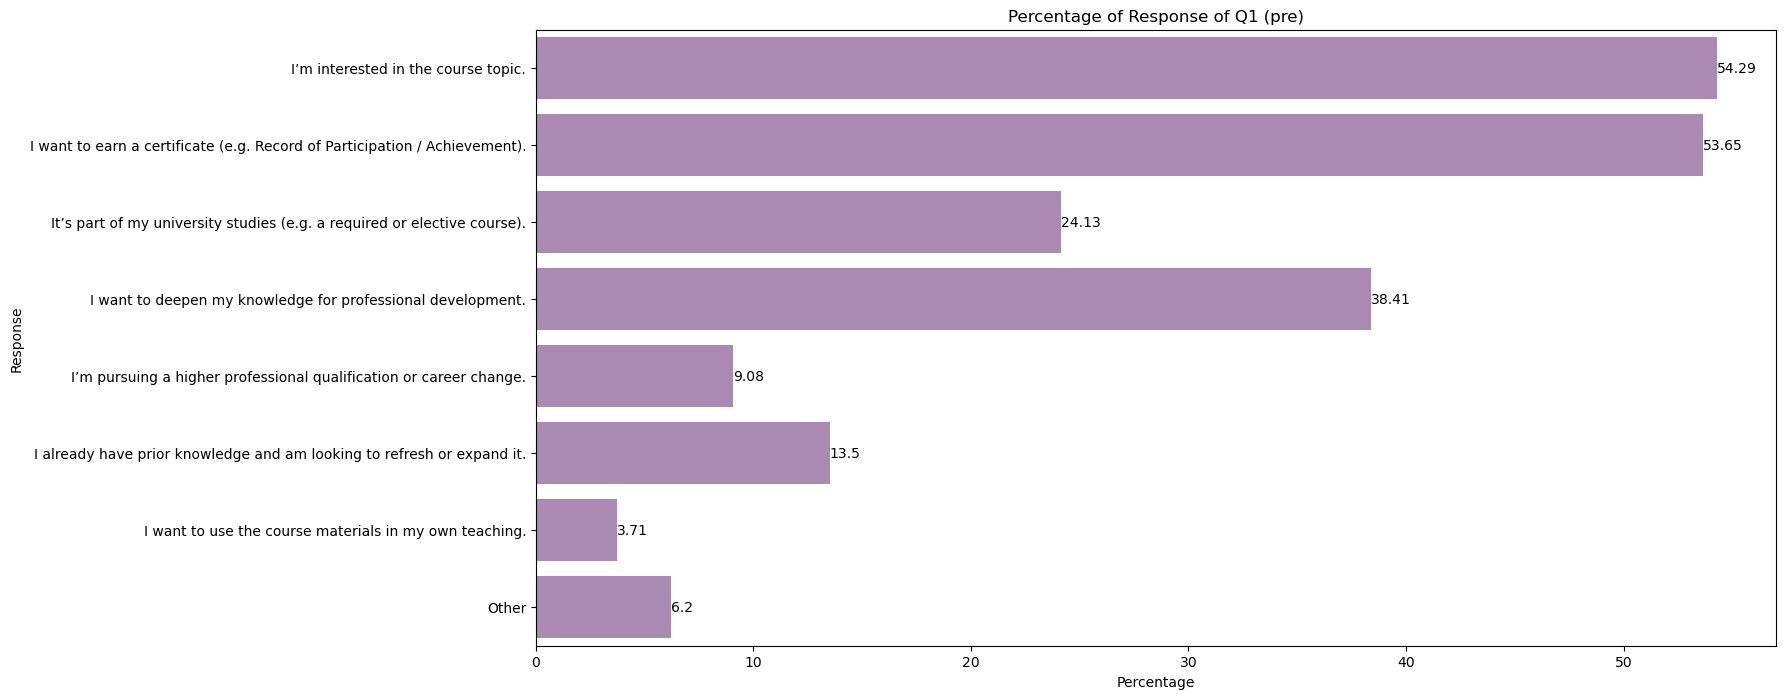

In [18]:
# slice the Question 1
Q1_pre = agg_pre[['Q01_Question 1->I’m interested in the course topic.', \
                  'Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).', \
                  'Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).', \
                  'Q01_Question 1->I want to deepen my knowledge for professional development.', \
                  'Q01_Question 1->I’m pursuing a higher professional qualification or career change.', \
                  'Q01_Question 1->I already have prior knowledge and am looking to refresh or expand it.', \
                  'Q01_Question 1->I want to use the course materials in my own teaching.', \
                  'Q01_Question 1->Other']]

Q1_pre.columns = ['I’m interested in the course topic.', \
                  'I want to earn a certificate (e.g. Record of Participation / Achievement).', \
                  'It’s part of my university studies (e.g. a required or elective course).', \
                  'I want to deepen my knowledge for professional development.', \
                  'I’m pursuing a higher professional qualification or career change.', \
                  'I already have prior knowledge and am looking to refresh or expand it.', \
                  'I want to use the course materials in my own teaching.', \
                  'Other']

Q1_pre.isna().sum()
Q1_pre.head()

# check the aggreated frequency
Q1_pct_count_pre = freq_pct_calculator(Q1_pre)

# plotting 
plotting_freq_pct(df = Q1_pct_count_pre, title = 'Percentage of Response of Q1 (pre)')


### Aggregated AI topics of interests (max. 3 responses per individual)

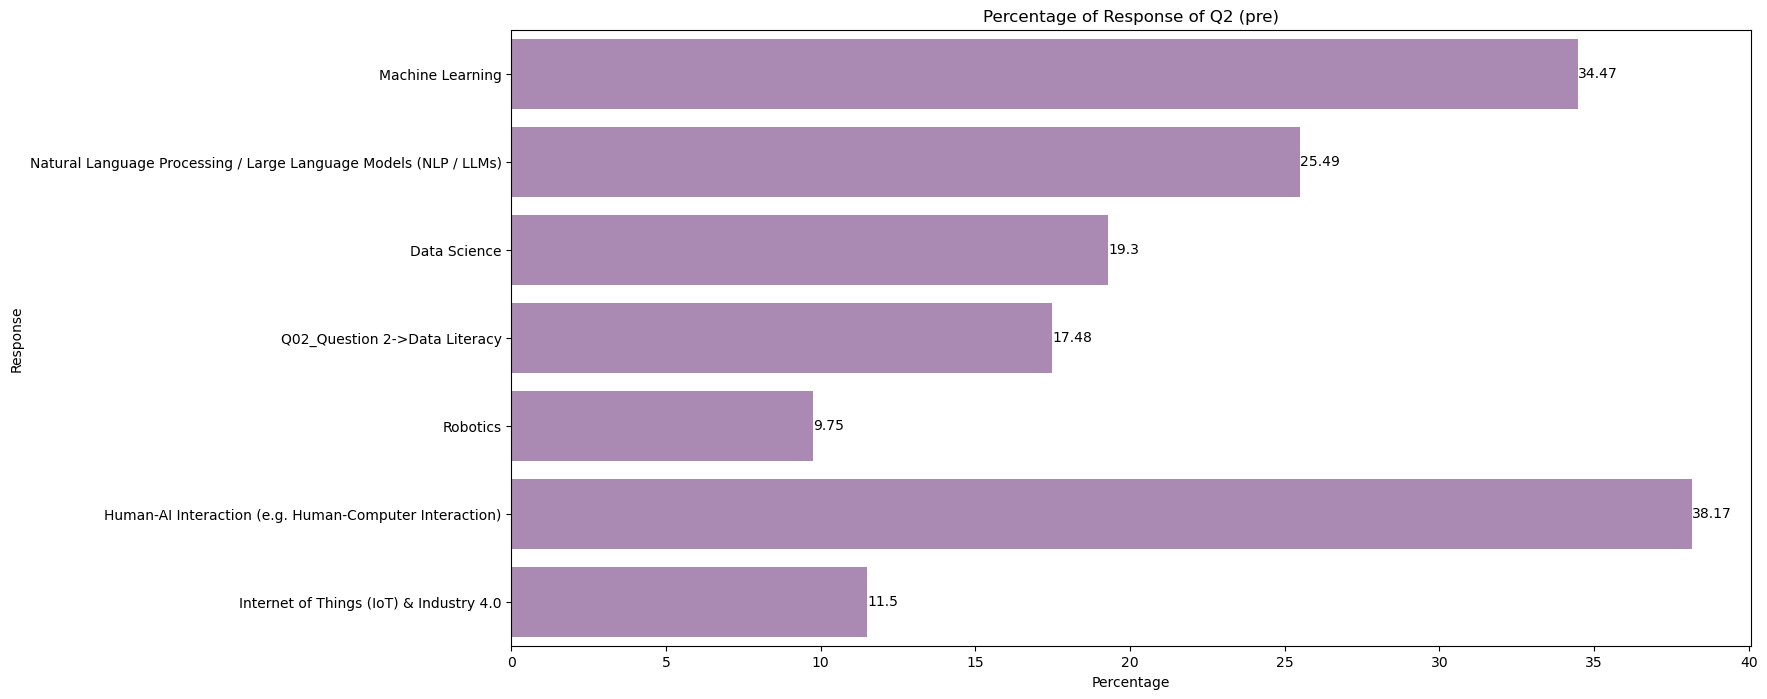

In [19]:
# slice the question 2
Q2_pre = agg_pre[['Q02_Question 2->Machine Learning', \
                  'Q02_Question 2->Natural Language Processing / Large Language Models (NLP / LLMs)', \
                  'Q02_Question 2->Data Science', 'Q02_Question 2->Data Literacy', \
                  'Q02_Question 2->Robotics', \
                  'Q02_Question 2->Human-AI Interaction (e.g. Human-Computer Interaction)', \
                  'Q02_Question 2->Internet of Things (IoT) & Industry 4.0']]

Q2_pre.columns = ['Machine Learning', \
                  'Natural Language Processing / Large Language Models (NLP / LLMs)', \
                  'Data Science', 'Q02_Question 2->Data Literacy', \
                  'Robotics', \
                  'Human-AI Interaction (e.g. Human-Computer Interaction)', \
                  'Internet of Things (IoT) & Industry 4.0']

Q2_pre.isnull().sum()

# check the aggreated frequency
Q2_pct_count_pre = freq_pct_calculator(Q2_pre)

# plotting 
plotting_freq_pct(df = Q2_pct_count_pre, title = 'Percentage of Response of Q2 (pre)')

### Aggregated areas of interests of AI (max. 3 responses per individual)

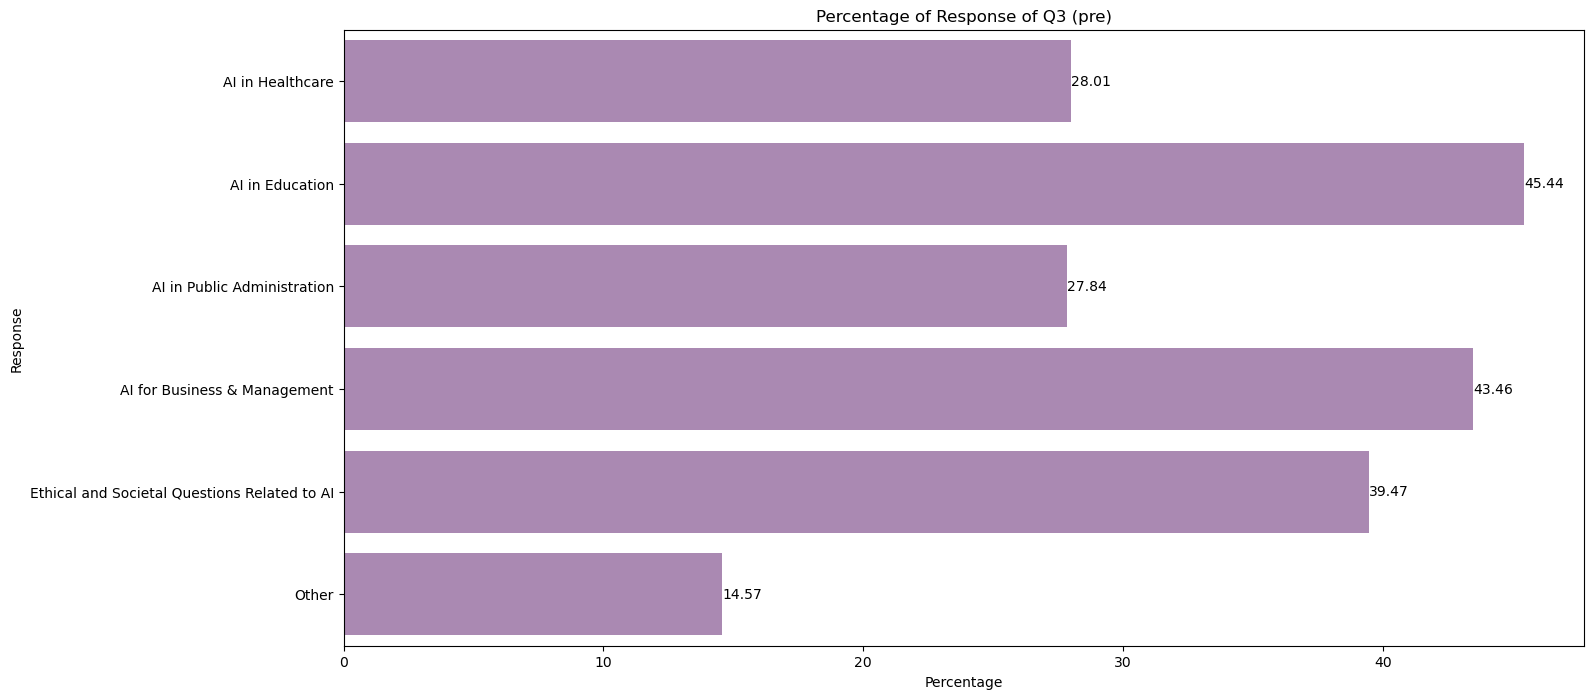

In [20]:
# slice the question Q3
Q3_pre = agg_pre[['Q03_Question 3->AI in Healthcare', \
                  'Q03_Question 3->AI in Education', \
                  'Q03_Question 3->AI in Public Administration', \
                  'Q03_Question 3->AI for Business & Management', \
                  'Q03_Question 3->Ethical and Societal Questions Related to AI', \
                  'Q03_Question 3->Other']]

Q3_pre.columns = ['AI in Healthcare', \
                  'AI in Education', \
                  'AI in Public Administration', \
                  'AI for Business & Management', \
                  'Ethical and Societal Questions Related to AI', \
                  'Other']

Q3_pre.isnull().sum()

# check the aggreated frequency
Q3_pct_count_pre = freq_pct_calculator(Q3_pre)

# plotting 
plotting_freq_pct(df = Q3_pct_count_pre, title = 'Percentage of Response of Q3 (pre)')


### Aggregated number of gender distribution (pre-surveys)

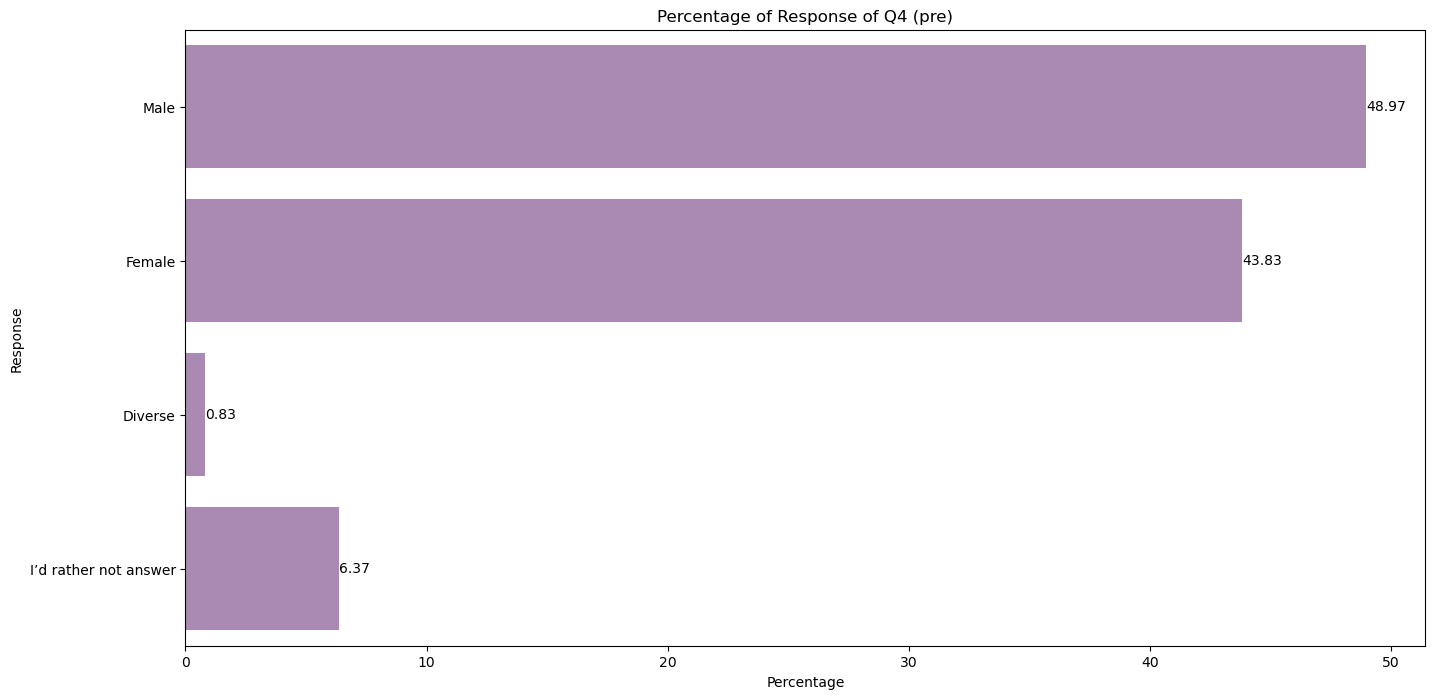

In [21]:
# slice the question Q4
Q4_pre = agg_pre[['Q04_Question 4->Male', \
           'Q04_Question 4->Female', 'Q04_Question 4->Diverse', \
           'Q04_Question 4->I’d rather not answer']]

Q4_pre.columns = ['Male', \
                  'Female', 'Diverse', \
                  'I’d rather not answer']

Q4_pre.isnull().sum()

# check the aggreated frequency
Q4_pct_count_pre = freq_pct_calculator(Q4_pre)

# plotting 
plotting_freq_pct(df = Q4_pct_count_pre, title = 'Percentage of Response of Q4 (pre)')


### Aggregated level of education (pre-surveys)

C:\Users\ywa\AppData\Local\Temp\ipykernel_36552\2829489856.py:12: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  Q5_pre.columnss = ['Doctorate / PhD', 'Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \


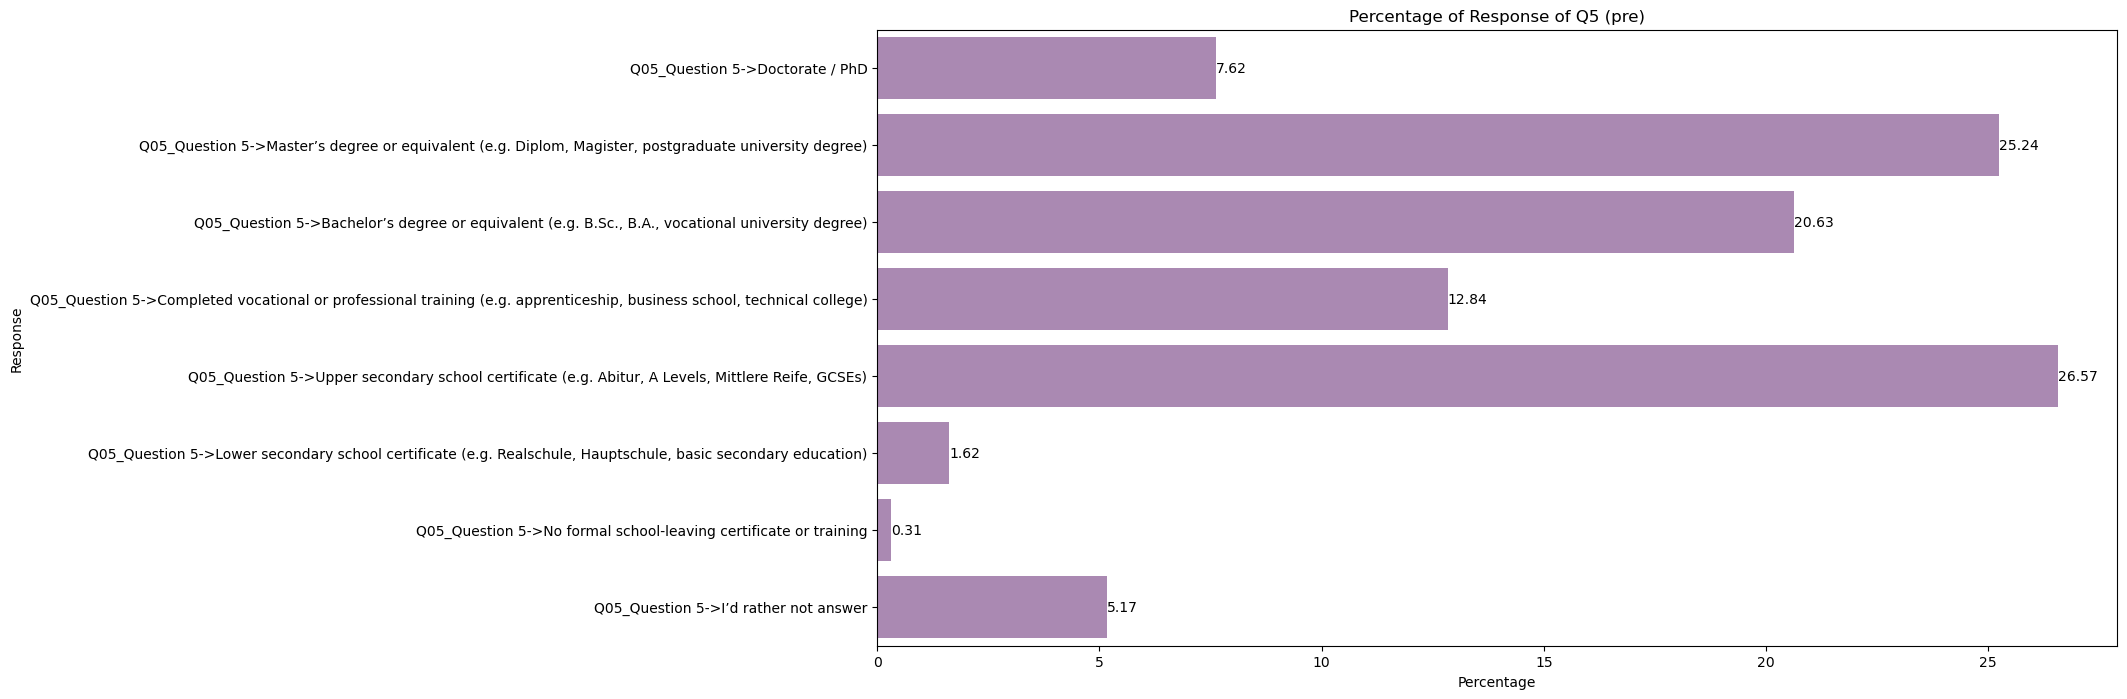

In [22]:
# slice the question Q5

Q5_pre = agg_pre[['Q05_Question 5->Doctorate / PhD', \
                  'Q05_Question 5->Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
                  'Q05_Question 5->Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
                  'Q05_Question 5->Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
                  'Q05_Question 5->Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
                  'Q05_Question 5->Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
                  'Q05_Question 5->No formal school-leaving certificate or training', \
                  'Q05_Question 5->I’d rather not answer']]

Q5_pre.columnss = ['Doctorate / PhD', 'Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
                   'Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
                   'Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
                   'Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
                   'Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
                   'No formal school-leaving certificate or training', \
                   'I’d rather not answer']

Q5_pre.isnull().sum()

# check the aggreated frequency
Q5_pct_count_pre = freq_pct_calculator(Q5_pre)

# plotting 
plotting_freq_pct(df = Q5_pct_count_pre, title = 'Percentage of Response of Q5 (pre)')

### Aggregated employment (pre-surveys)

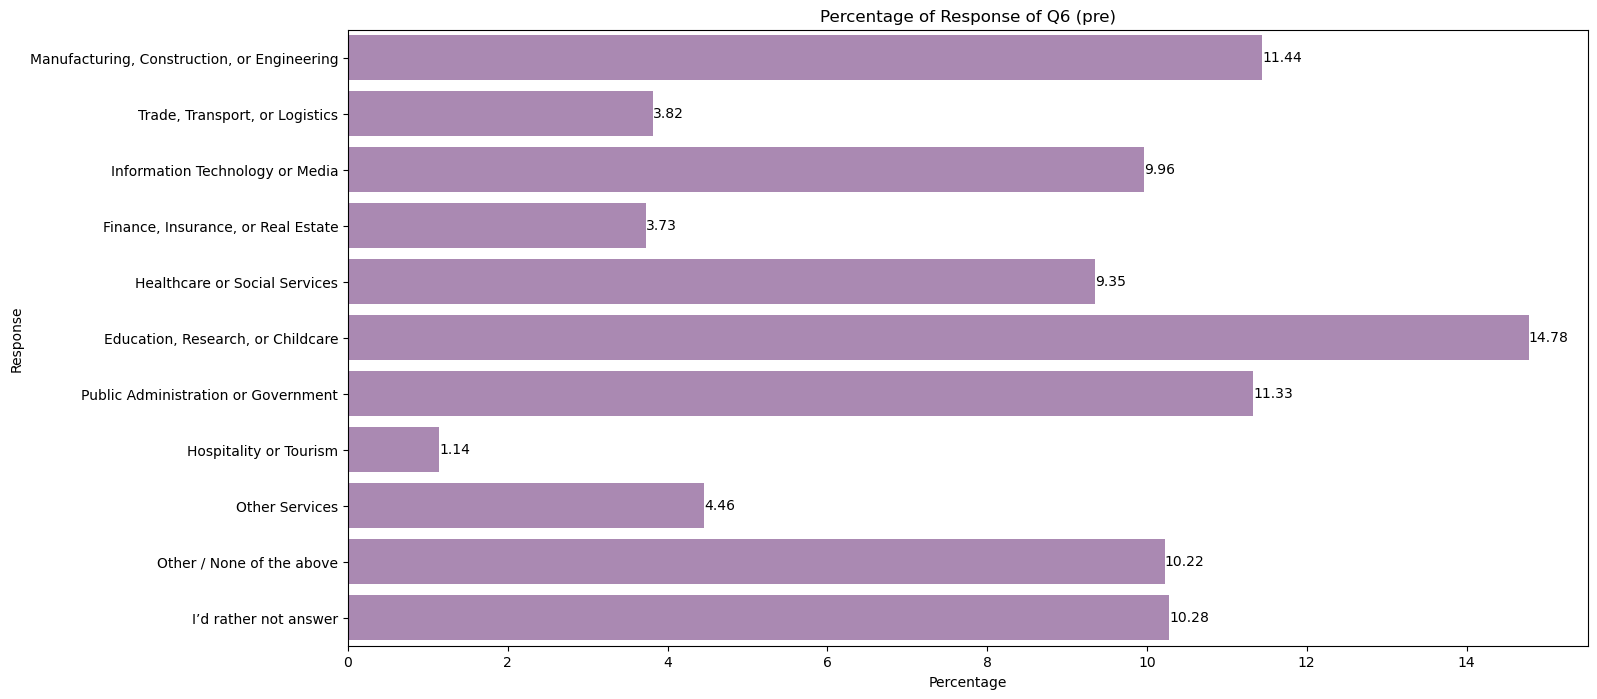

In [23]:
# slice the question Q6

Q6_pre = agg_pre[['Q06_Question 6->Manufacturing, Construction, or Engineering', \
                 'Q06_Question 6->Trade, Transport, or Logistics', \
                 'Q06_Question 6->Information Technology or Media', \
                 'Q06_Question 6->Finance, Insurance, or Real Estate', \
                 'Q06_Question 6->Healthcare or Social Services', \
                 'Q06_Question 6->Education, Research, or Childcare', \
                 'Q06_Question 6->Public Administration or Government', \
                 'Q06_Question 6->Hospitality or Tourism', \
                 'Q06_Question 6->Other Services', \
                 'Q06_Question 6->Other / None of the above', \
                 'Q06_Question 6->I’d rather not answer']]

Q6_pre.columns = ['Manufacturing, Construction, or Engineering', \
                  'Trade, Transport, or Logistics', \
                  'Information Technology or Media', \
                  'Finance, Insurance, or Real Estate', \
                  'Healthcare or Social Services', \
                  'Education, Research, or Childcare', \
                  'Public Administration or Government', \
                  'Hospitality or Tourism', \
                  'Other Services', \
                  'Other / None of the above', \
                  'I’d rather not answer']

Q6_pre.isnull().sum()

# check the aggreated frequency
Q6_pct_count_pre = freq_pct_calculator(Q6_pre)

# plotting 
plotting_freq_pct(df = Q6_pct_count_pre, title = 'Percentage of Response of Q6 (pre)')

### Course impression

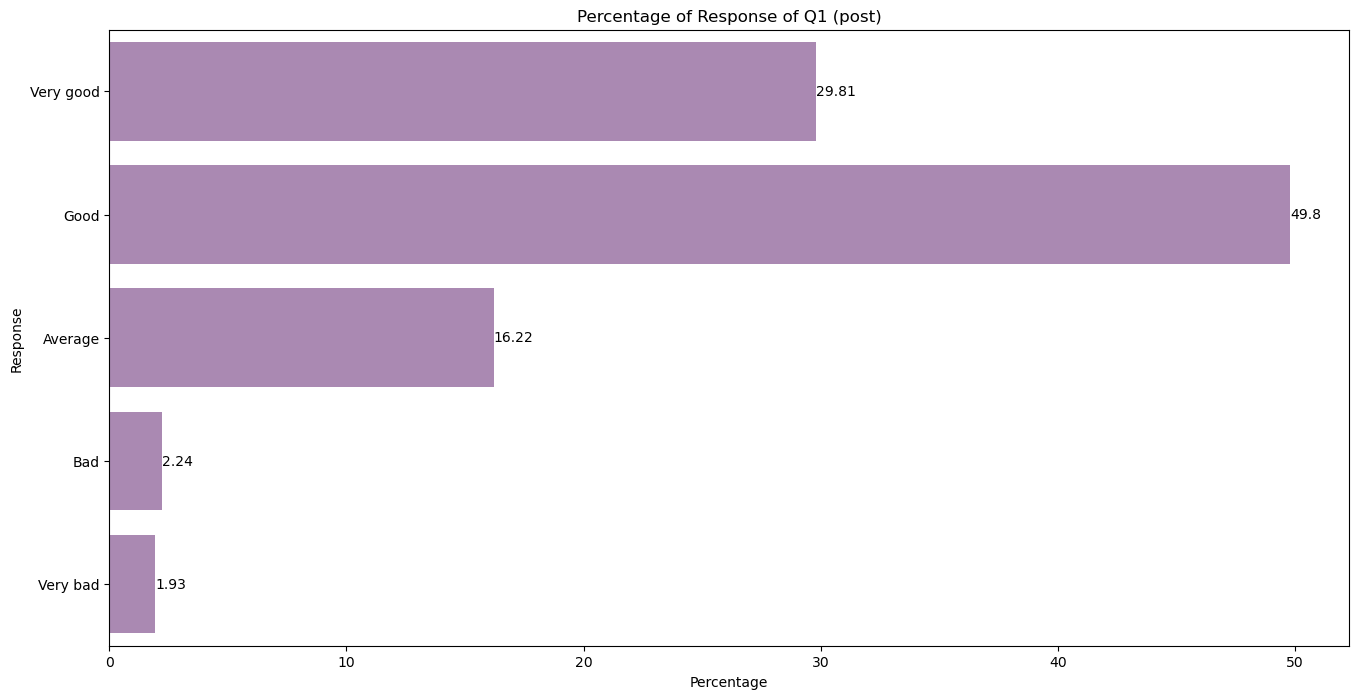

In [24]:
# slice the question Q1
Q1_post = agg_post[['Q01_Question 1->Very good', \
                    'Q01_Question 1->Good', \
                    'Q01_Question 1->Average', \
                    'Q01_Question 1->Bad', \
                    'Q01_Question 1->Very bad']]

Q1_post.columns = ['Very good', \
                   'Good', \
                   'Average', \
                   'Bad', \
                   'Very bad']

Q1_post.isnull().sum()

# check the aggreated frequency
Q1_pct_count_post = freq_pct_calculator(Q1_post)

# plotting 
plotting_freq_pct(df = Q1_pct_count_post, title = 'Percentage of Response of Q1 (post)')

### Course recommendation

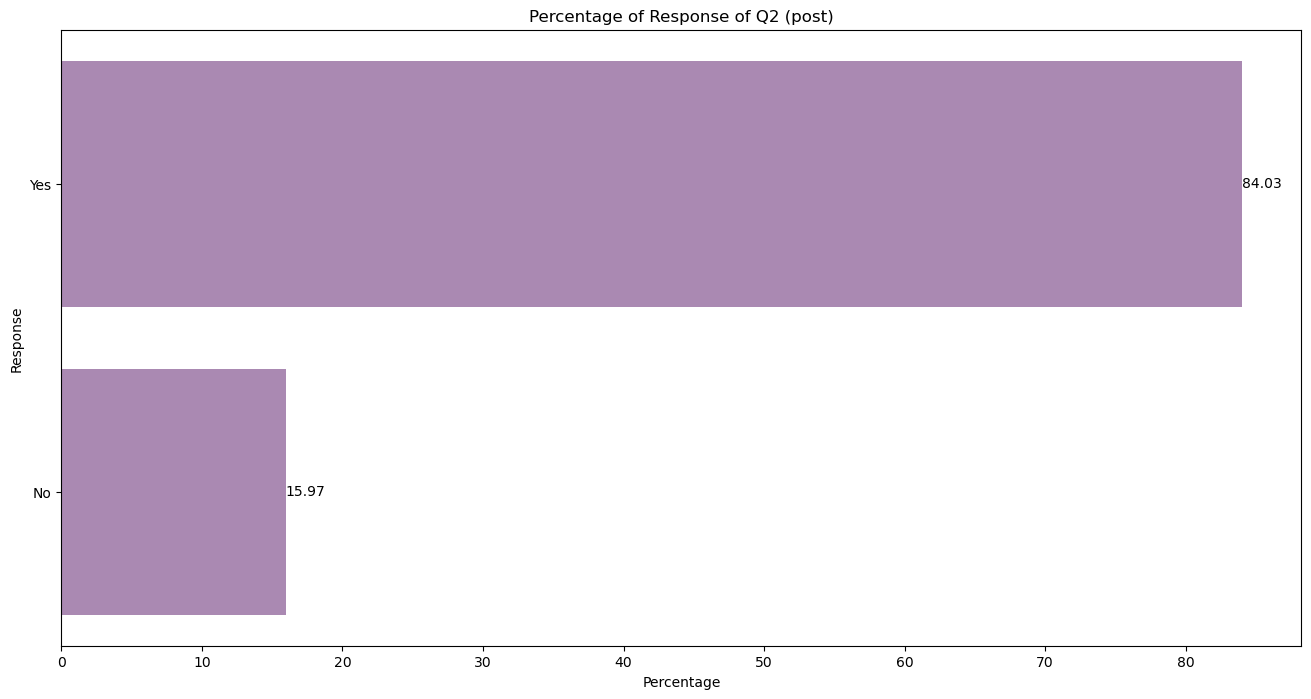

In [25]:
Q2_post = agg_post[['Q02_Question 2->Yes', 'Q02_Question 2->No']]

Q2_post.columns = ['Yes', 'No']

Q2_post.isnull().sum()

# check the aggreated frequency
Q2_pct_count_post = freq_pct_calculator(Q2_post)

# plotting 
plotting_freq_pct(df = Q2_pct_count_post, title = 'Percentage of Response of Q2 (post)')

### Reasons for not recommending the course

C:\Users\ywa\AppData\Local\Temp\ipykernel_36552\4293986516.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  Q3_post.columsn = ['The content was not accurate or up-to-date', \


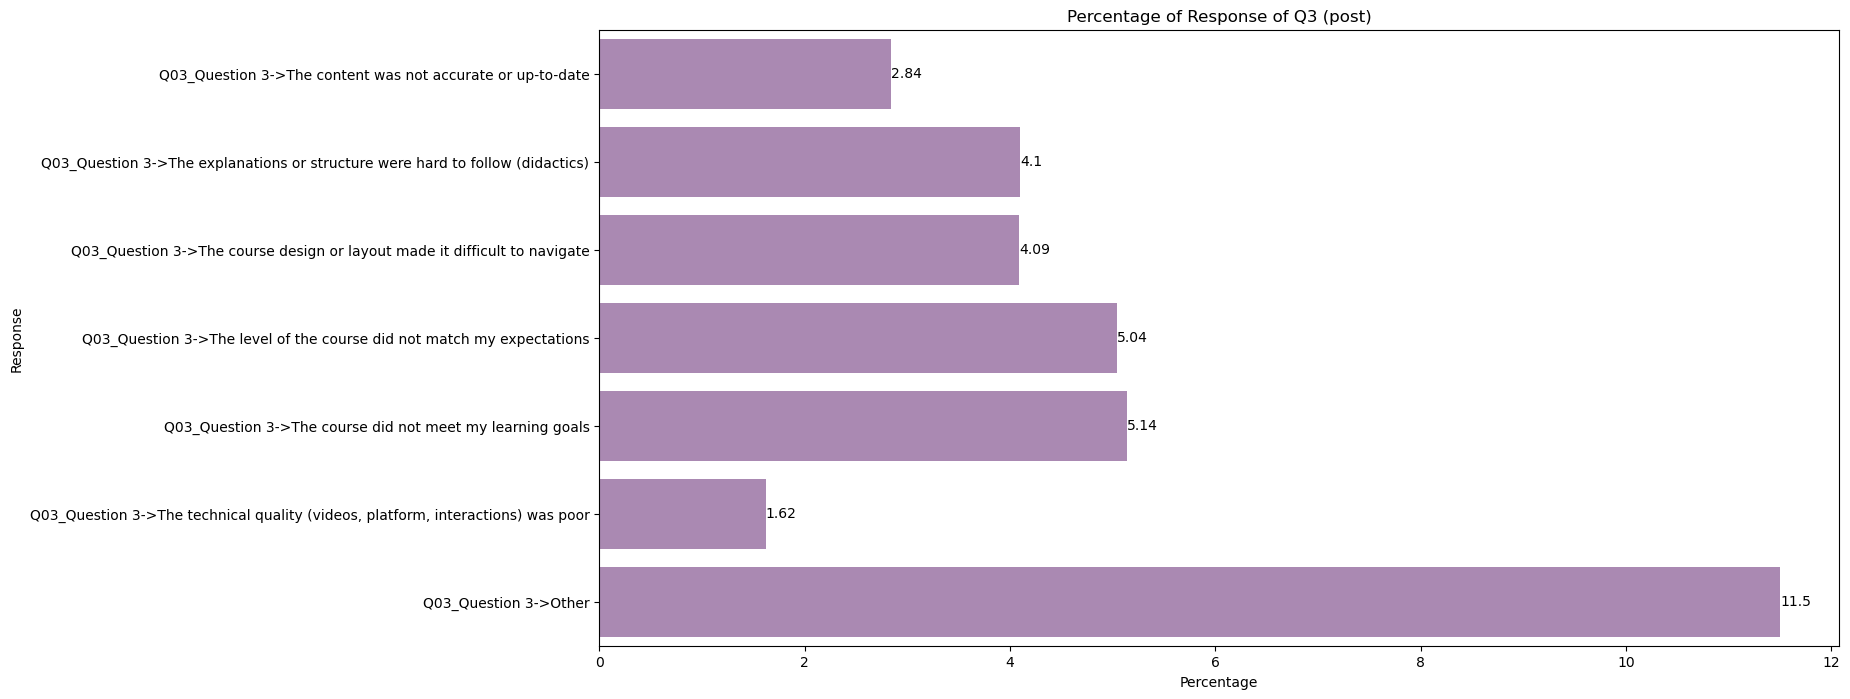

In [26]:
Q3_post = agg_post[['Q03_Question 3->The content was not accurate or up-to-date', \
                    'Q03_Question 3->The explanations or structure were hard to follow (didactics)', \
                    'Q03_Question 3->The course design or layout made it difficult to navigate', \
                    'Q03_Question 3->The level of the course did not match my expectations', \
                    'Q03_Question 3->The course did not meet my learning goals', \
                    'Q03_Question 3->The technical quality (videos, platform, interactions) was poor', \
                    'Q03_Question 3->Other']]

Q3_post.columsn = ['The content was not accurate or up-to-date', \
                   'The explanations or structure were hard to follow (didactics)', \
                   'The course design or layout made it difficult to navigate', \
                   'The level of the course did not match my expectations', \
                   'The course did not meet my learning goals', \
                   'The technical quality (videos, platform, interactions) was poor', \
                   'Other']

Q3_post.isnull().sum()

# check the aggreated frequency
Q3_pct_count_post = freq_pct_calculator(Q3_post)

# plotting 
plotting_freq_pct(df = Q3_pct_count_post, title = 'Percentage of Response of Q3 (post)')


### Subjective preceived learning goal

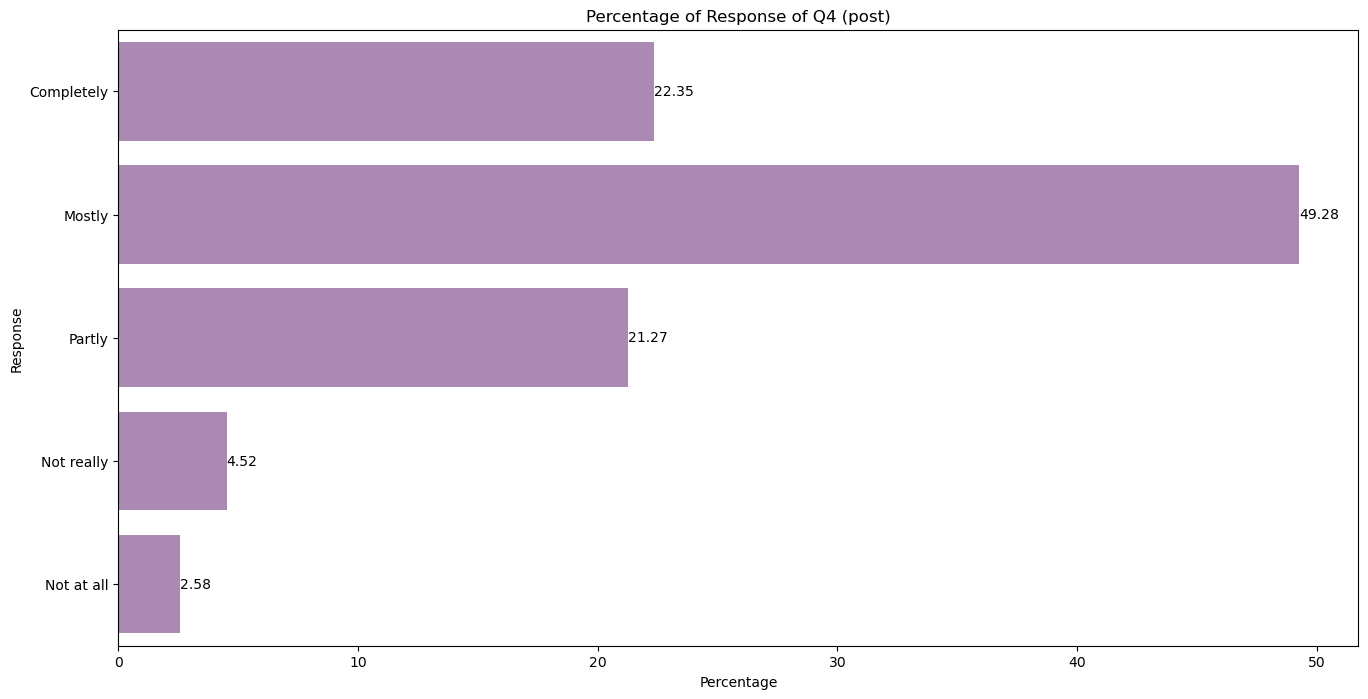

In [27]:
Q4_post = agg_post[['Q04_Question 4->Completely', \
                    'Q04_Question 4->Mostly', \
                    'Q04_Question 4->Partly', \
                    'Q04_Question 4->Not really', \
                    'Q04_Question 4->Not at all']]

Q4_post.columns = ['Completely', \
                   'Mostly', \
                   'Partly', \
                   'Not really', \
                   'Not at all']

Q4_post.isnull().sum()

# check the aggreated frequency
Q4_pct_count_post = freq_pct_calculator(Q4_post)

# plotting 
plotting_freq_pct(df = Q4_pct_count_post, title = 'Percentage of Response of Q4 (post)')

### Subjective knowedge estimation pre-course

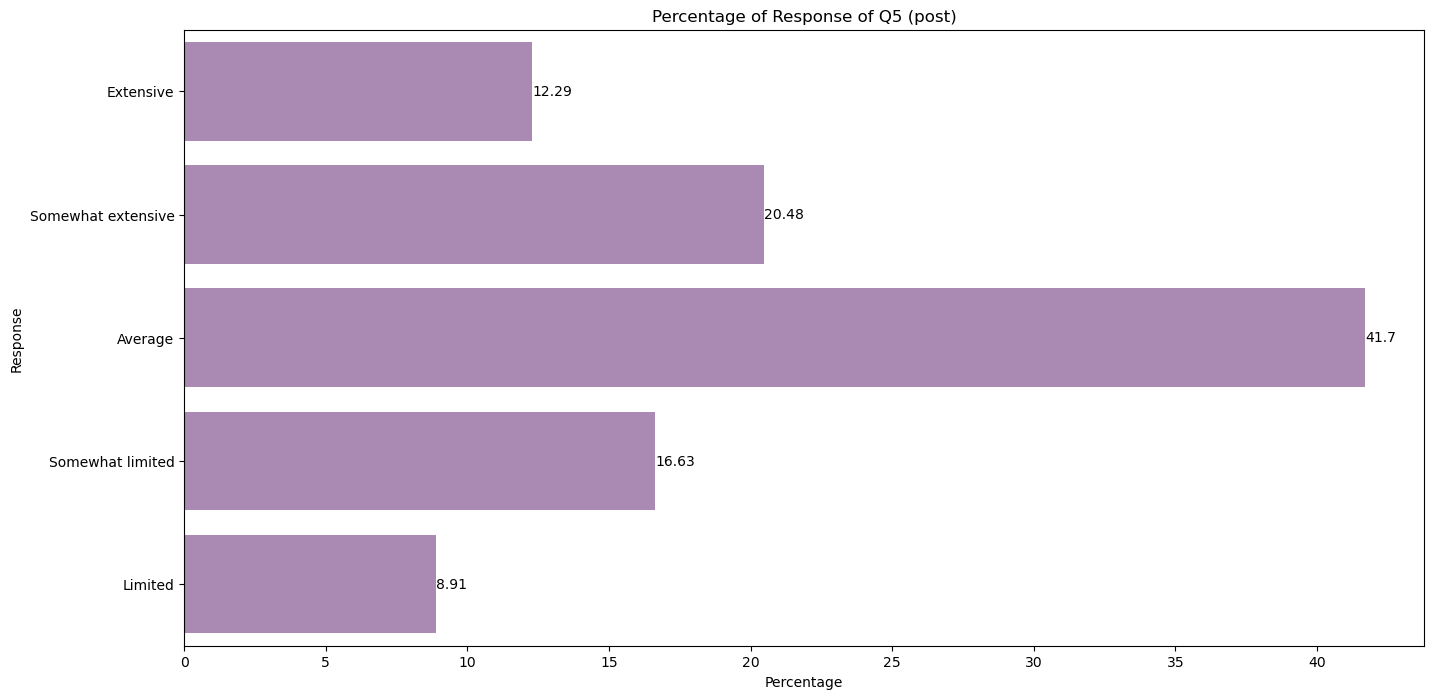

In [28]:
Q5_post = agg_post[['Q05_Question 5->Extensive', \
                    'Q05_Question 5->Somewhat extensive', \
                    'Q05_Question 5->Average', \
                    'Q05_Question 5->Somewhat limited', \
                    'Q05_Question 5->Limited']]

Q5_post.columns = ['Extensive', \
                   'Somewhat extensive', \
                   'Average', \
                   'Somewhat limited', \
                   'Limited']

Q5_post.isnull().sum()

# check the aggreated frequency
Q5_pct_count_post = freq_pct_calculator(Q5_post)

# plotting 
plotting_freq_pct(df = Q5_pct_count_post, title = 'Percentage of Response of Q5 (post)')

### Subjective knowledge estimation post-course

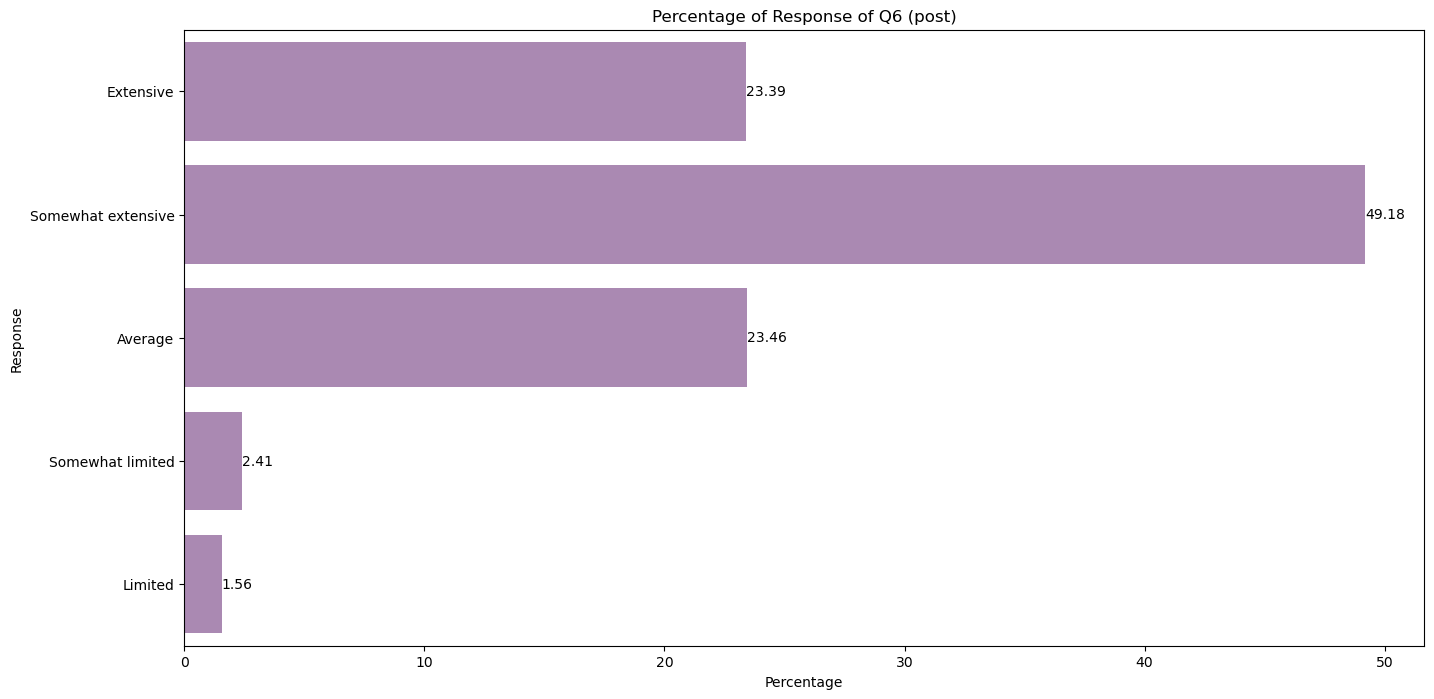

In [29]:
Q6_post = agg_post[['Q06_Question 6->Extensive', \
                    'Q06_Question 6->Somewhat extensive', \
                    'Q06_Question 6->Average', \
                    'Q06_Question 6->Somewhat limited', \
                    'Q06_Question 6->Limited']]

Q6_post.columns = ['Extensive', \
                   'Somewhat extensive', \
                   'Average', \
                   'Somewhat limited', \
                   'Limited']

Q6_post.isnull().sum()

# check the aggreated frequency
Q6_pct_count_post = freq_pct_calculator(Q6_post)

# plotting 
plotting_freq_pct(df = Q6_pct_count_post, title = 'Percentage of Response of Q6 (post)')


### Most supportive activity type (max. 3 responses per individual)

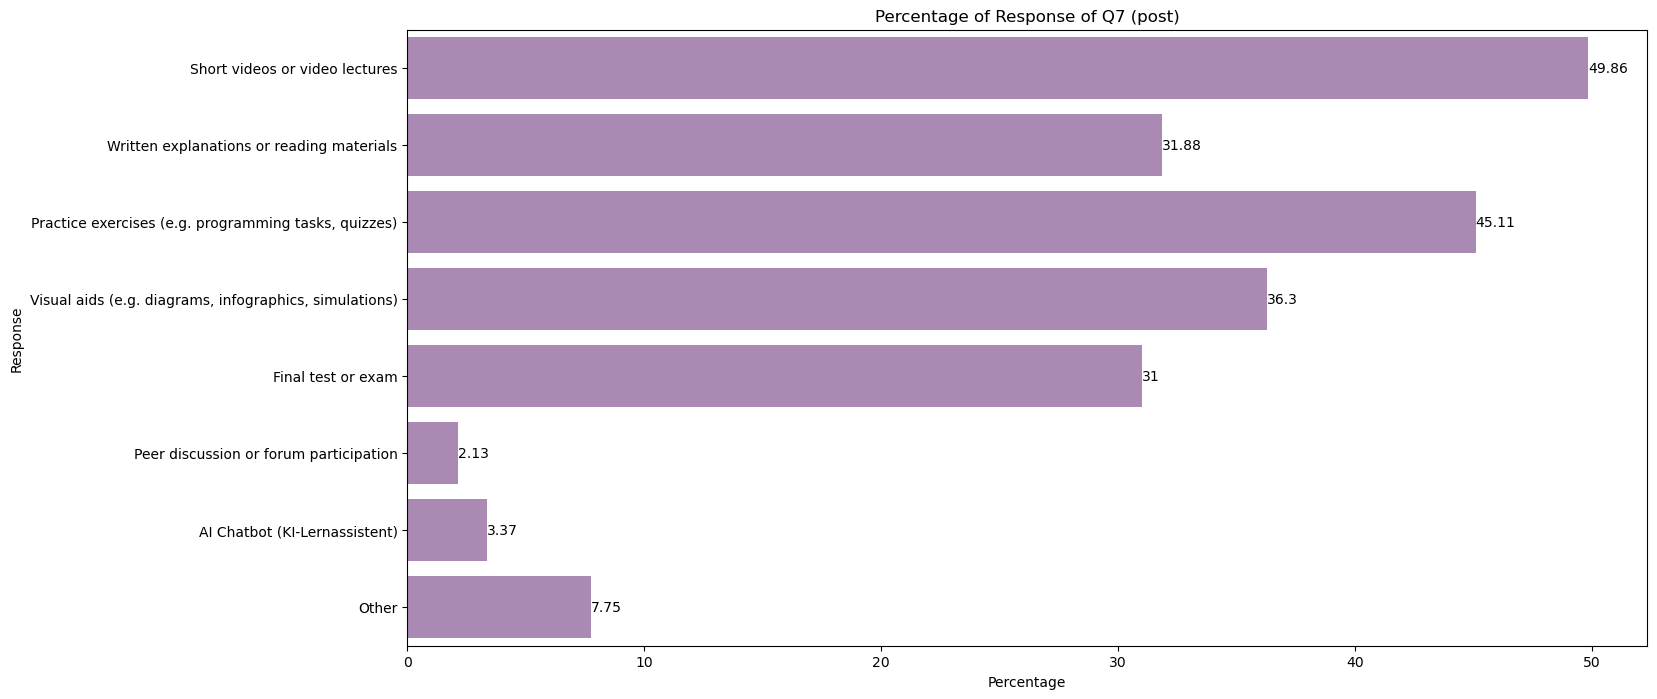

In [30]:
Q7_post = agg_post[['Q07_Question 7->Short videos or video lectures', \
                    'Q07_Question 7->Written explanations or reading materials', \
                    'Q07_Question 7->Practice exercises (e.g. programming tasks, quizzes)', \
                    'Q07_Question 7->Visual aids (e.g. diagrams, infographics, simulations)', \
                    'Q07_Question 7->Final test or exam', \
                    'Q07_Question 7->Peer discussion or forum participation', \
                    'Q07_Question 7->AI Chatbot (KI-Lernassistent)', \
                    'Q07_Question 7->Other']]

Q7_post.columns = ['Short videos or video lectures', \
                   'Written explanations or reading materials', \
                   'Practice exercises (e.g. programming tasks, quizzes)', \
                   'Visual aids (e.g. diagrams, infographics, simulations)', \
                   'Final test or exam', \
                   'Peer discussion or forum participation', \
                   'AI Chatbot (KI-Lernassistent)', \
                   'Other']

Q7_post.isnull().sum()

# check the aggreated frequency
Q7_pct_count_post = freq_pct_calculator(Q7_post)

# plotting 
plotting_freq_pct(df = Q7_pct_count_post, title = 'Percentage of Response of Q7 (post)')


### Chatbot (learning assisstant) use

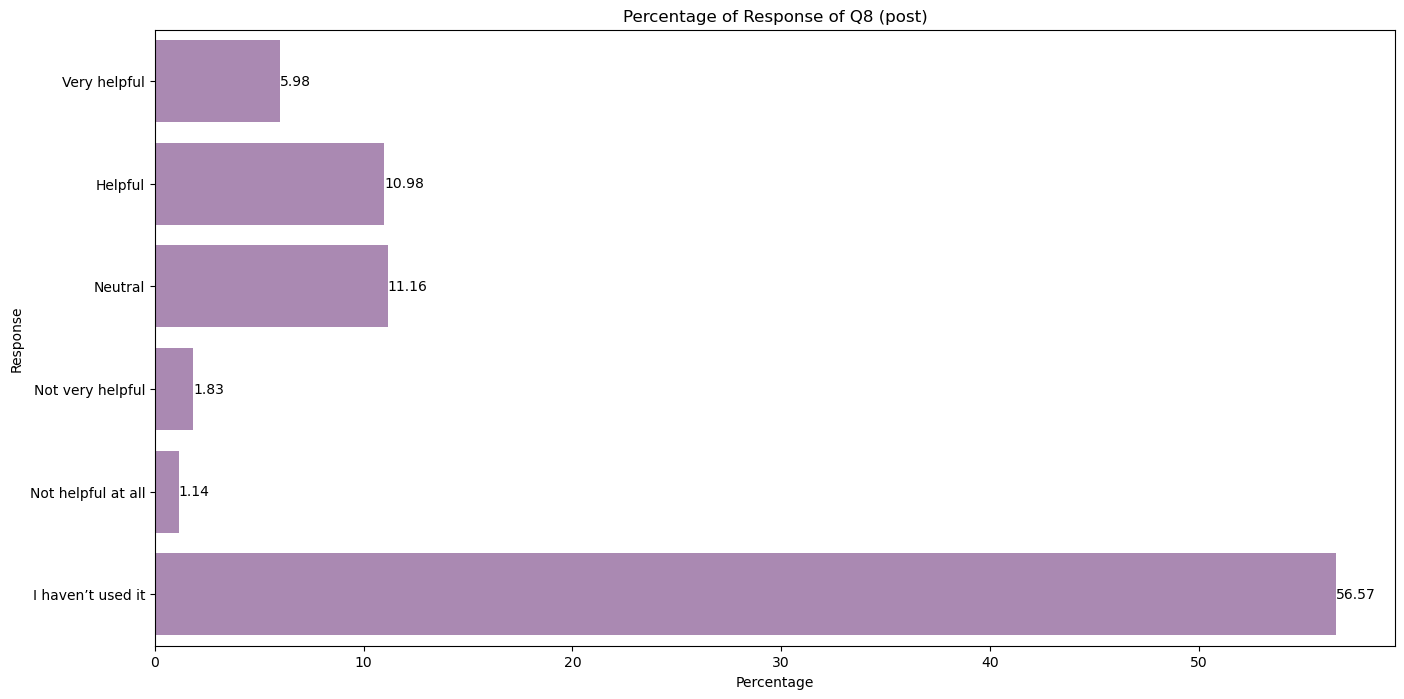

In [31]:
Q8_post = agg_post[['Q08_Question 8->Very helpful', \
                    'Q08_Question 8->Helpful', \
                    'Q08_Question 8->Neutral', \
                    'Q08_Question 8->Not very helpful', \
                    'Q08_Question 8->Not helpful at all', \
                    'Q08_Question 8->I haven’t used it']]

Q8_post.columns = ['Very helpful', \
                   'Helpful', \
                   'Neutral', \
                   'Not very helpful', \
                   'Not helpful at all', \
                   'I haven’t used it']

Q8_post.isnull().sum()

# check the aggreated frequency
Q8_pct_count_post = freq_pct_calculator(Q8_post)

# plotting 
plotting_freq_pct(df = Q8_pct_count_post, title = 'Percentage of Response of Q8 (post)')

### Purpose of Chatbot use

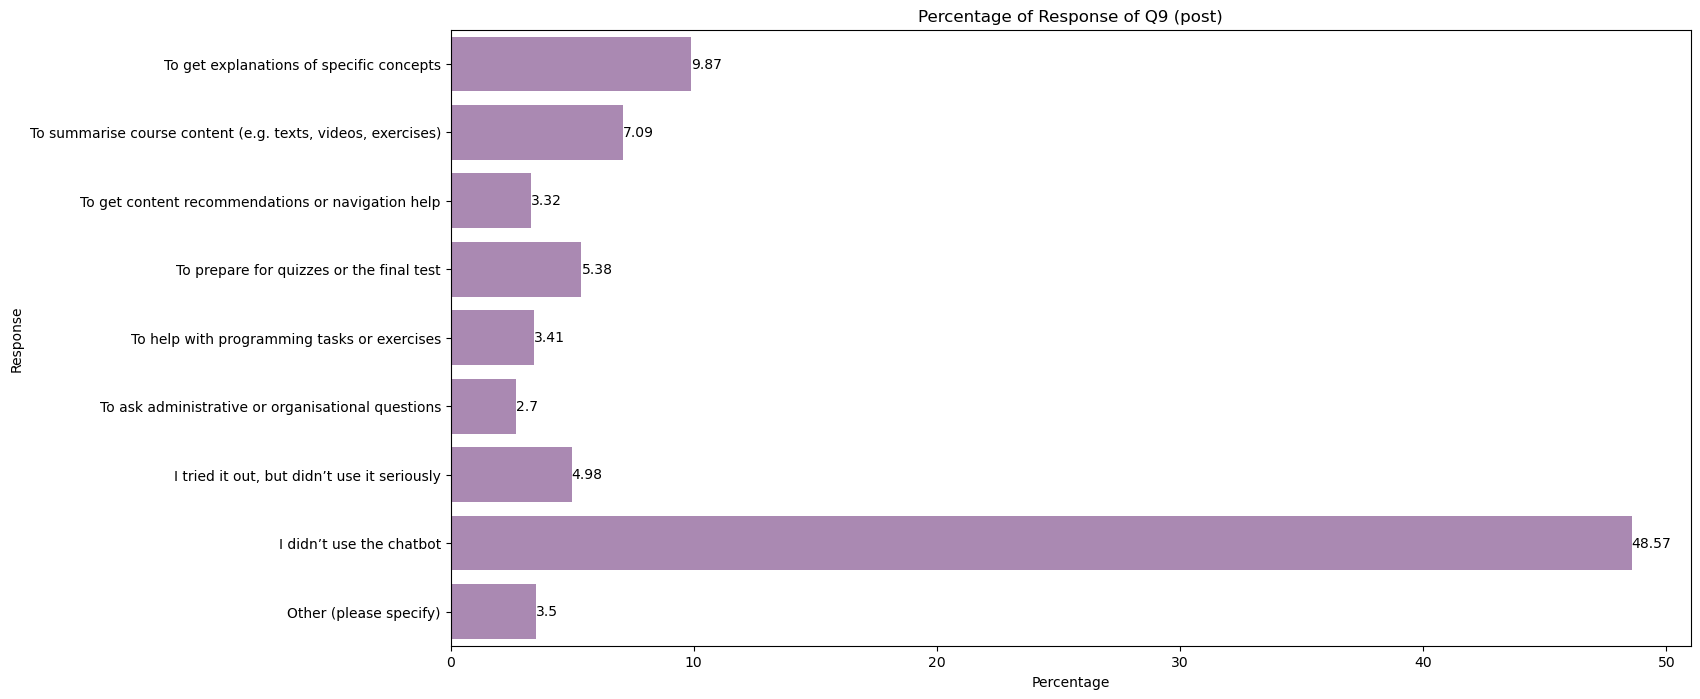

In [32]:
Q9_post = agg_post[['Q09_Question 9->To get explanations of specific concepts', \
                    'Q09_Question 9->To summarise course content (e.g. texts, videos, exercises)', \
                    'Q09_Question 9->To get content recommendations or navigation help', \
                    'Q09_Question 9->To prepare for quizzes or the final test', \
                    'Q09_Question 9->To help with programming tasks or exercises', \
                    'Q09_Question 9->To ask administrative or organisational questions', \
                    'Q09_Question 9->I tried it out, but didn’t use it seriously', \
                    'Q09_Question 9->I didn’t use the chatbot', \
                    'Q09_Question 9->Other (please specify)']]

Q9_post.columns = ['To get explanations of specific concepts', \
                   'To summarise course content (e.g. texts, videos, exercises)', \
                   'To get content recommendations or navigation help', \
                   'To prepare for quizzes or the final test', \
                   'To help with programming tasks or exercises', \
                   'To ask administrative or organisational questions', \
                   'I tried it out, but didn’t use it seriously', \
                   'I didn’t use the chatbot', \
                   'Other (please specify)']

Q9_post.isnull().sum()

# check the aggreated frequency
Q9_pct_count_post = freq_pct_calculator(Q9_post)

# plotting 
plotting_freq_pct(df = Q9_pct_count_post, title = 'Percentage of Response of Q9 (post)')

### Aggregated number of gender distribution (post-surveys)

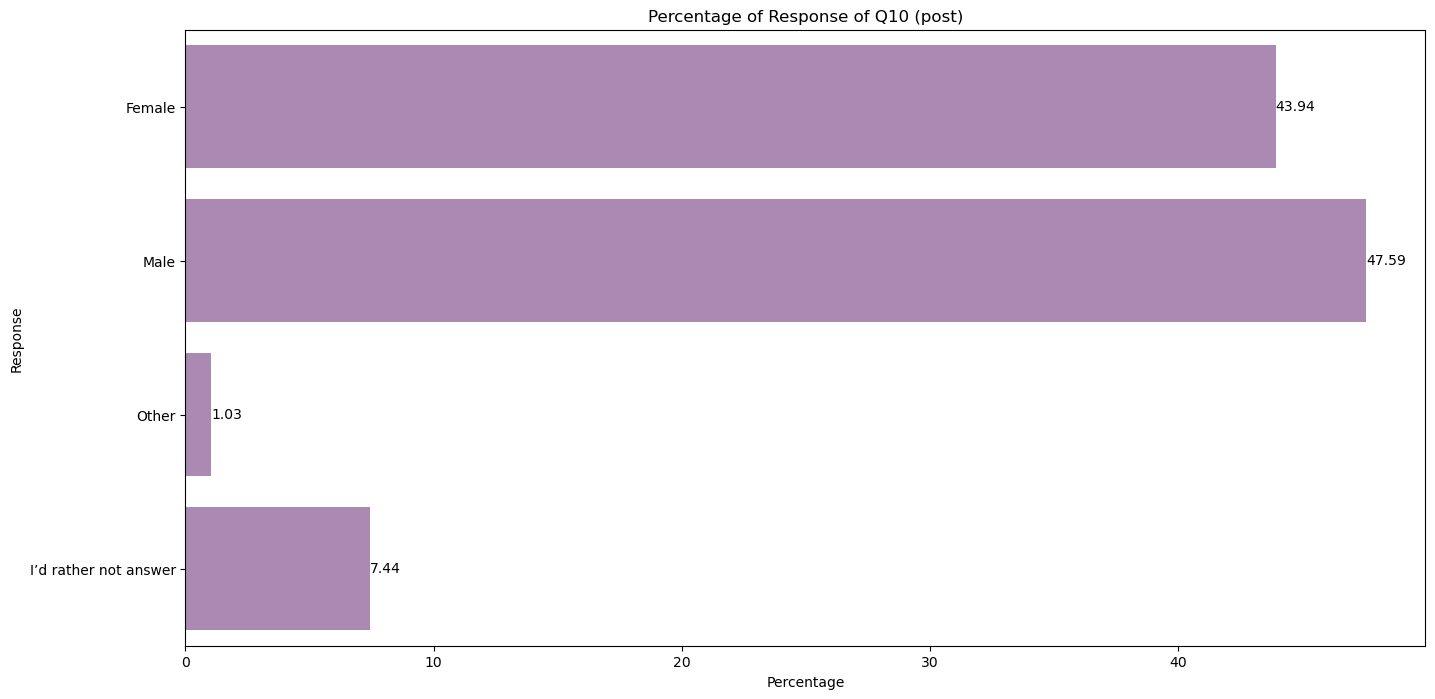

In [33]:
Q10_post = agg_post[['Q10_Question 10->Female', \
                     'Q10_Question 10->Male', \
                     'Q10_Question 10->Other', \
                     'Q10_Question 10->I’d rather not answer']]

Q10_post.columns = ['Female', \
                    'Male', \
                    'Other', \
                    'I’d rather not answer']

Q10_post.isnull().sum()

# check the aggreated frequency
Q10_pct_count_post = freq_pct_calculator(Q10_post)

# plotting 
plotting_freq_pct(df = Q10_pct_count_post, title = 'Percentage of Response of Q10 (post)')

### Aggregated level of education (pre-surveys)

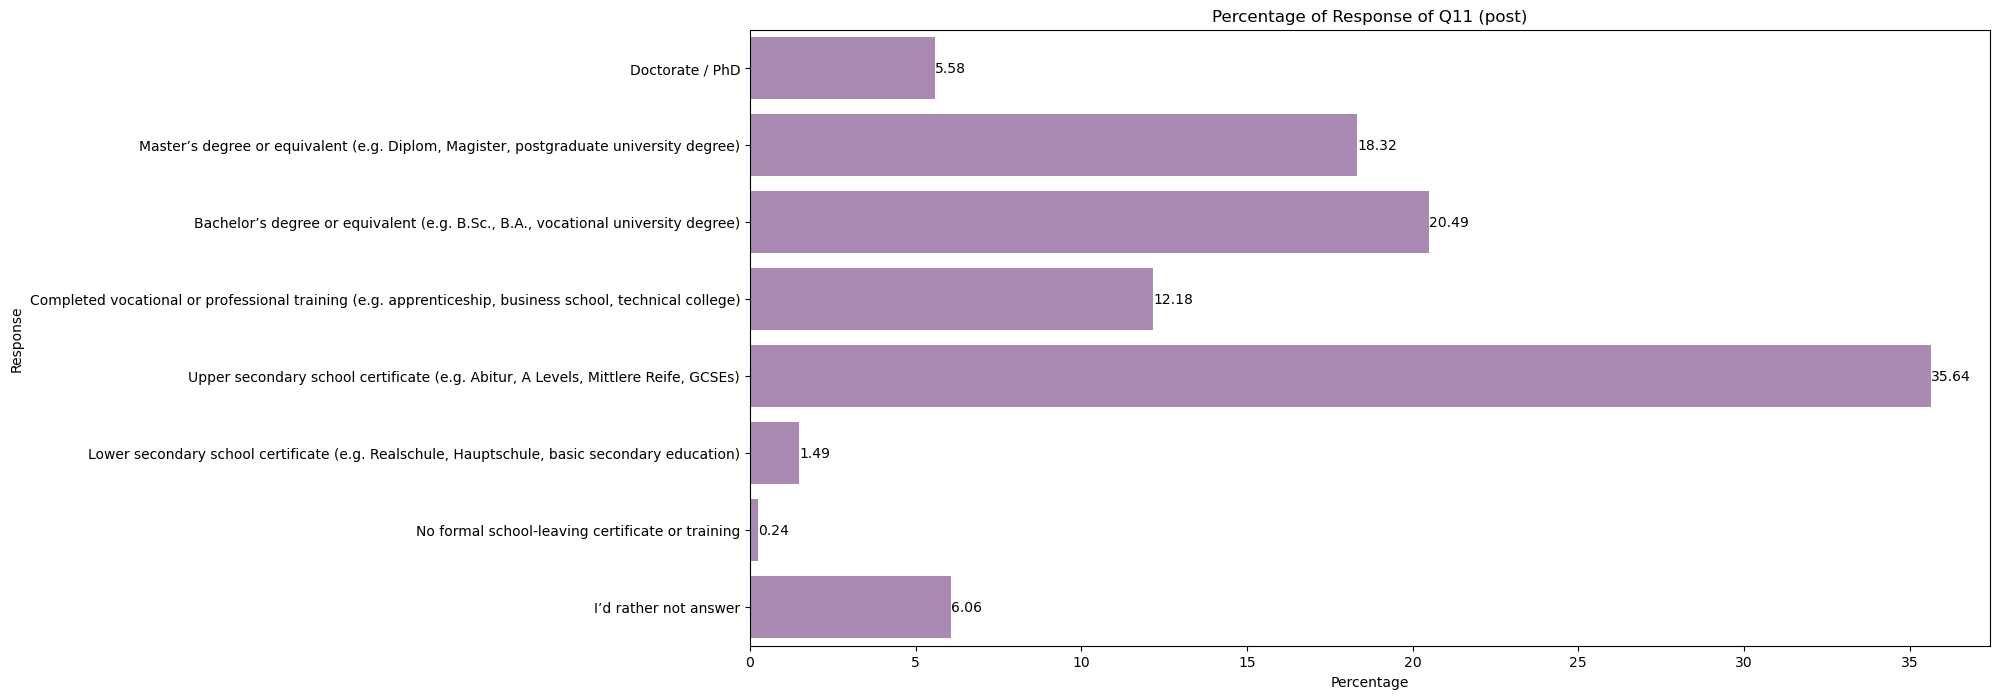

In [34]:
Q11_post = agg_post[['Q11_Question 11->Doctorate / PhD', \
                     'Q11_Question 11->Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
                     'Q11_Question 11->Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
                     'Q11_Question 11->Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
                     'Q11_Question 11->Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
                     'Q11_Question 11->Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
                     'Q11_Question 11->No formal school-leaving certificate or training', \
                     'Q11_Question 11->I’d rather not answer']]

Q11_post.columns = ['Doctorate / PhD', \
                    'Master’s degree or equivalent (e.g. Diplom, Magister, postgraduate university degree)', \
                    'Bachelor’s degree or equivalent (e.g. B.Sc., B.A., vocational university degree)', \
                    'Completed vocational or professional training (e.g. apprenticeship, business school, technical college)', \
                    'Upper secondary school certificate (e.g. Abitur, A Levels, Mittlere Reife, GCSEs)', \
                    'Lower secondary school certificate (e.g. Realschule, Hauptschule, basic secondary education)', \
                    'No formal school-leaving certificate or training', \
                    'I’d rather not answer']

Q11_post.isnull().sum()

# check the aggreated frequency
Q11_pct_count_post = freq_pct_calculator(Q11_post)

# plotting 
plotting_freq_pct(df = Q11_pct_count_post, title = 'Percentage of Response of Q11 (post)')


### Aggregated employment (pre-surveys)

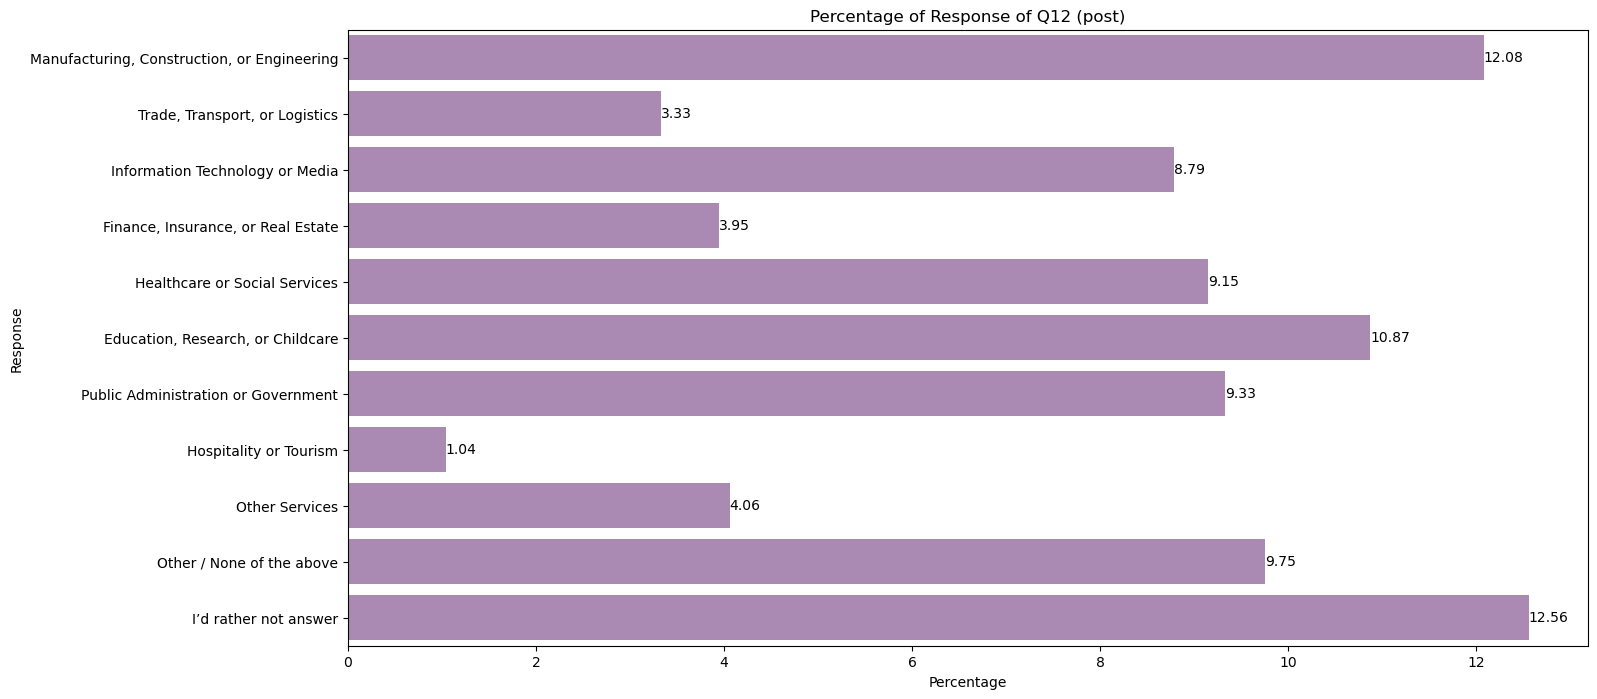

In [35]:
Q12_post = agg_post[['Q12_Question 12->Manufacturing, Construction, or Engineering', \
                     'Q12_Question 12->Trade, Transport, or Logistics', \
                     'Q12_Question 12->Information Technology or Media', \
                     'Q12_Question 12->Finance, Insurance, or Real Estate', \
                     'Q12_Question 12->Healthcare or Social Services', \
                     'Q12_Question 12->Education, Research, or Childcare', \
                     'Q12_Question 12->Public Administration or Government', \
                     'Q12_Question 12->Hospitality or Tourism', \
                     'Q12_Question 12->Other Services', \
                     'Q12_Question 12->Other / None of the above', \
                     'Q12_Question 12->I’d rather not answer']]

Q12_post.columns =  ['Manufacturing, Construction, or Engineering', \
                     'Trade, Transport, or Logistics', \
                     'Information Technology or Media', \
                     'Finance, Insurance, or Real Estate', \
                     'Healthcare or Social Services', \
                     'Education, Research, or Childcare', \
                     'Public Administration or Government', \
                     'Hospitality or Tourism', \
                     'Other Services', \
                     'Other / None of the above', \
                     'I’d rather not answer']

Q12_post.isnull().sum()

# check the aggreated frequency
Q12_pct_count_post = freq_pct_calculator(Q12_post)

# plotting 
plotting_freq_pct(df = Q12_pct_count_post, title = 'Percentage of Response of Q12 (post)')

### Subjective knowledge growth (based on the response from Q5-post and Q6-post)

In [36]:
# nuber of changes to each answer to another subjective knowledge growth (post course - pre course)
# as the survey responses are one-hot encoded. It needs to be reversed for the cross tab (one dimension required)

# reversing...
weights = np.arange(1, 6)

Q5_post['Q5_score'] = (Q5_post * weights).sum(axis = 1)
Q5_post.head()

Q6_post['Q6_score'] = (Q6_post * weights).sum(axis = 1)
Q5_post.head()

C:\Users\ywa\AppData\Local\Temp\ipykernel_36552\210880277.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q5_post['Q5_score'] = (Q5_post * weights).sum(axis = 1)
C:\Users\ywa\AppData\Local\Temp\ipykernel_36552\210880277.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q6_post['Q6_score'] = (Q6_post * weights).sum(axis = 1)


,Extensive,Somewhat extensive,Average,Somewhat limited,Limited,Q5_score
0,0.0,0.0,0.0,1.0,0.0,4.0
1,0.0,0.0,1.0,0.0,0.0,3.0
2,0.0,0.0,1.0,0.0,0.0,3.0
3,0.0,0.0,1.0,0.0,0.0,3.0
4,0.0,0.0,1.0,0.0,0.0,3.0


In [37]:
# map the column value to strings

value2str = {1 : 'Extensive', 
             2 : 'Somewhat extensive',
             3 : 'Averge', 
             4 : 'Somewhat limited', 
             5 : 'Limited'}

Q5_post['Subjective knowledge before course'] = Q5_post['Q5_score'].map(value2str)
Q6_post['Subjective knowledge after course'] = Q6_post['Q6_score'].map(value2str)

C:\Users\ywa\AppData\Local\Temp\ipykernel_36552\2966570864.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q5_post['Subjective knowledge before course'] = Q5_post['Q5_score'].map(value2str)
C:\Users\ywa\AppData\Local\Temp\ipykernel_36552\2966570864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q6_post['Subjective knowledge after course'] = Q6_post['Q6_score'].map(value2str)


In [38]:
# validation
print(Q5_post['Q5_score'].max(), Q5_post['Q5_score'].min())
print(Q6_post['Q6_score'].max(), Q6_post['Q6_score'].min())


5.0 1.0
5.0 1.0


In [39]:
# cross tab
ct_knowledgeGrowth = pd.crosstab(Q5_post['Subjective knowledge before course'], Q6_post['Subjective knowledge after course'])
ct_knowledgeGrowth

Subjective knowledge after course,Averge,Extensive,Limited,Somewhat extensive,Somewhat limited
Subjective knowledge before course,,,,,
Averge,1142,597,12,2839,39
Extensive,87,1021,32,210,14
Limited,463,50,115,237,124
Somewhat extensive,220,791,7,1232,23
Somewhat limited,692,137,7,942,68


In [40]:
# percentage of frequency for each option
ct_knowledgeGrowth_pct = round(ct_knowledgeGrowth.div(ct_knowledgeGrowth.sum(axis = 1), axis = 0) * 100, 2)

ct_knowledgeGrowth_pct


Subjective knowledge after course,Averge,Extensive,Limited,Somewhat extensive,Somewhat limited
Subjective knowledge before course,,,,,
Averge,24.67,12.90,0.26,61.33,0.84
Extensive,6.38,74.85,2.35,15.40,1.03
Limited,46.81,5.06,11.63,23.96,12.54
Somewhat extensive,9.68,34.80,0.31,54.20,1.01
Somewhat limited,37.49,7.42,0.38,51.03,3.68


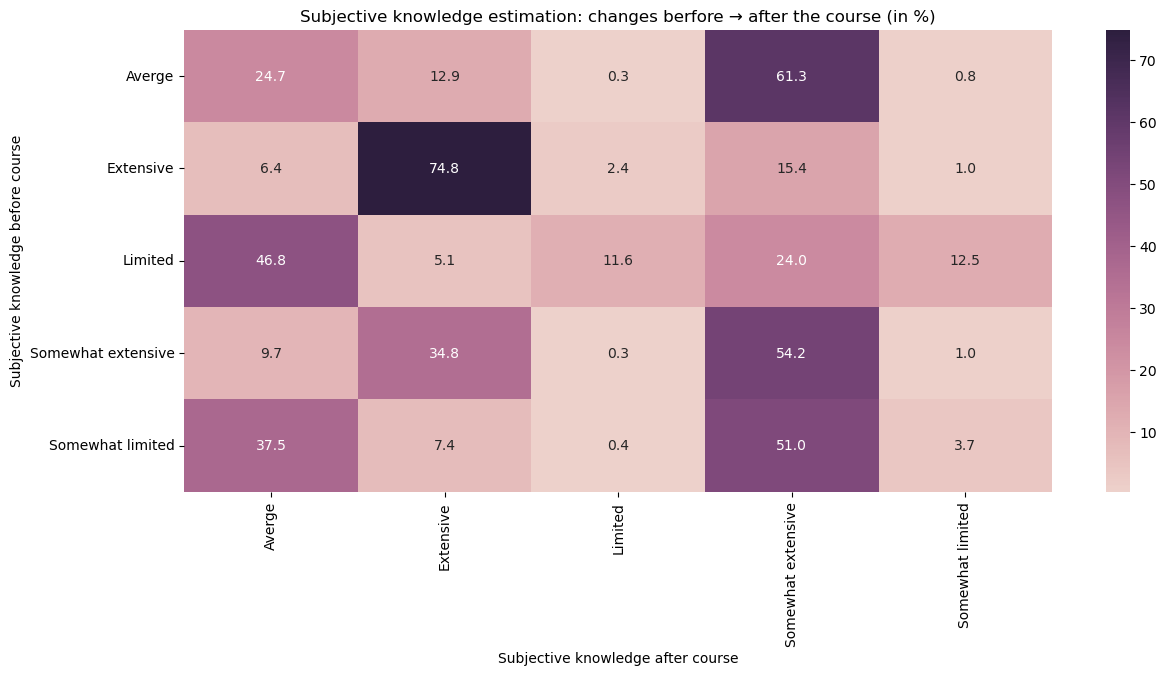

In [41]:
# visualisation with heatmap
plt.figure(figsize=(14,6))
sns.heatmap(ct_knowledgeGrowth_pct, annot=True, fmt=".1f", cmap= sns.cubehelix_palette(as_cmap=True))
plt.title("Subjective knowledge estimation: changes berfore → after the course (in %)")
plt.xticks(rotation = 90)
plt.show()

From the analysis above, a subjective knowledge growth is found among the survey participants:
* for learners who have rated themselves as "average" before starting the courses, 61.3% of them rated their knowledge on the topic "somewhat extensive" after the courses.
* for learners who have rated themselves as "extensive" before starting the courses, 74.8% of them rated their knowledge on the topic "extensive" after the courses.
* for learners who have rated themselves as "limited" before starting the courses, 46.8% of them rated their knowledge on the topic "average" after the courses.
* for learners who have rated themselves as "somewhat extensive" before starting the courses, 54.2% of them rated their knowledge on the topic "somewhat extensive" after the courses.
* for learners who have rated themselves as "somewhat limited" before staring the courses, 37.5% of them rated their knowledge on the topic"average" and 51.0% rated their knowledge on the topic "somewhat extensive"after the courses.

In [42]:
# merging with course category --> 
agg_pre_cat = agg_pre.merge(base_df, how = 'left', on = ['courseID', 'Course'], validate ='many_to_one')
agg_post_cat = agg_post.merge(base_df, how = 'left', on = ['courseID', 'Course'], validate = 'many_to_one')


### Clustering user responses

In [43]:
# import dependencies
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [44]:
# feature_selection
pre_feature = agg_pre.drop(['courseID', 'Course', 'Q02'], axis = 1)
post_feature = agg_post.drop(['courseID', 'Course', 'Q08', 'Q09', 'Q08_Gut gefallen', 'Q09_Anregungen'], axis = 1)

# clean feature names --> unclear regarding the question relationship
#pre_feature.columns = pre_feature.columns.str.split('->').str[-1].str.strip()
#post_feature.columns = post_feature.columns.str.split('->').str[-1].str.strip()

# check the datatype
print(pre_feature.info())
print(post_feature.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19750 entries, 0 to 19749
Data columns (total 46 columns):
 #   Column                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                   --------------  -----  
 0   Q01_Question 1->I’m interested in the course topic.                                                                      19750 non-null  float64
 1   Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).                               19750 non-null  float64
 2   Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).                                 19750 non-null  float64
 3   Q01_Question 1->I want to deepen my knowledge for professional development.                                              19750 non-null 

In [45]:
# build unsupervised learning pipeline --> PCA + KMeans
#random_state = 777
#pca = PCA(n_components = 0.90, random_state = random_state)

# for the pre set
#scores_pre = []
#ks = range(2, 9)
#for k in ks:
#    kmeans = KMeans(n_clusters = k, random_state = random_state, n_init = 10)
#    pre_embed = Pipeline(steps = [('pca', pca)]).fit_transform(pre_feature)
#    labels_pre = kmeans.fit_predict(pre_embed)
#    scores_pre.append(silhouette_score(pre_embed, labels_pre))
#print(list(zip(ks, scores_pre)))


# for the post set
#scores_post = []
#for k in ks:
#    kmeans = KMeans(n_clusters = k, random_state = random_state, n_init = 10)
#    post_embed = Pipeline(steps = [('pca', pca)]).fit_transform(post_feature)
#    labels_post = kmeans.fit_predict(post_embed)
#    scores_post.append(silhouette_score(post_embed, labels_post))
#print(list(zip(ks, scores_post)))

The features are one-hot-encoded in nature, which is not suitabel for KMeans clustring due to the distances in higher dimensions become similar (curse of dimensionality). **use Hamming distance-based method insteand of Euclidian distance-based method.**

In [46]:
# find the best n_components for TruncatedSVD, as TrancatedSVD works directly on sparse matrices
# use manual grid (nested loops)
random_state = 777

# deinfe function for the best hyperparameters
def param_finder(n_list, k_list, random_state, features):
    best_score = -1
    best_param = None
    results = []
    for n in n_list:
        svd = TruncatedSVD(n_components = n, random_state = random_state)
        X_reduced = svd.fit_transform(features)
        
        for k in k_list:
            kmeans = KMeans(n_clusters = k, random_state = random_state, n_init = 20)
            labels = kmeans.fit_predict(X_reduced)
            
            score = silhouette_score(X_reduced, labels)
            results.append((n, k, score))
            
            if score > best_score:
                best_score = score
                best_param = {'n_components' : n, 'k' : k}
    return best_score, best_param, results

In [47]:
ns_pre = np.arange(5, 20, 5)
ns_post = np.arange(10, 35, 5)
ks = range(2, 9)

# for the pre set
best_score_pre, best_param_pre, results_pre = param_finder(ns_pre, ks, random_state, pre_feature)

# for the post set
best_score_post, best_param_post, results_post = param_finder(ns_post, ks, random_state, post_feature)

In [48]:
# check results
print(best_score_pre, best_param_pre)
print(best_score_post, best_param_post)

0.23998154466993463 {'n_components': 5, 'k': 2}
0.16264199312357525 {'n_components': 10, 'k': 2}


In [49]:
# densify the search space
ns_pre = np.arange(2, 10)
ns_post = np.arange(6, 20, 2)
ks = range(2, 6)

# round 2
# for the pre set
best_score_pre, best_param_pre, results_pre = param_finder(ns_pre, ks, random_state, pre_feature)

# for the post set
best_score_post, best_param_post, results_post = param_finder(ns_post, ks, random_state, post_feature)

In [50]:
# check results
print(best_score_pre, best_param_pre)
print(best_score_post, best_param_post)

0.4339550271838066 {'n_components': 2, 'k': 2}
0.22239326710774515 {'n_components': 6, 'k': 4}


In [51]:
# pipeline clustering with best scores

pipe_pre = Pipeline(steps = [
    ('svd', TruncatedSVD(n_components = 2, random_state = random_state)), 
    ('kmeans',  KMeans(n_clusters = 2, random_state = random_state, n_init = 20))])

pipe_post = Pipeline(steps = [
    ('svd', TruncatedSVD(n_components = 6, random_state = random_state)), 
    ('kmeans',  KMeans(n_clusters = 4, random_state = random_state, n_init = 20))
])

labels_pre = pipe_pre.fit_predict(pre_feature)
labels_post = pipe_post.fit_predict(post_feature)


In [52]:
# check cluster stability --> check on whether small changes will impact the cluster structure

# interate the clustring with different random seeds calculate the Adjusted Rand Index (ARI)
# aim for ARI close to 1 (identical clustering)
# fucntion to get labels

def get_labels(X, n_components, k, runs = 20):
    label_list = []
    
    for seed in range(runs):
        pipe = Pipeline(steps = [('svd', TruncatedSVD(n_components = n_components, random_state = seed)), 
                                ('kmeans', KMeans(n_clusters = k, random_state = seed, n_init = 20))])
        
        labels = pipe.fit_predict(X)
        label_list.append(labels)
    return label_list
 
def ari_calculator(label_list):
    n = len(label_list)
    ari_scores = []
    
    for i in range(n):
        for j in range(i + 1, n):
            ari = adjusted_rand_score(label_list[i], label_list[j])
            ari_scores.append(ari)
            
    return np.mean(ari_scores), np.std(ari_scores)

# pre set
pre_LabelList = get_labels(pre_feature, 2, 2, runs = 20)
avg_pre, std_pre = ari_calculator(pre_LabelList)

print('ARI for pre set: ', avg_pre, std_pre)

# post set
post_LabelList = get_labels(post_feature, 6, 4, runs = 20)
avg_post, std_post = ari_calculator(post_LabelList)

print('ARI for post set: ', avg_post, std_post)


ARI for pre set:  0.9986053212992211 0.0009820333151689617
ARI for post set:  0.9965156095136506 0.0013401892812027717


Adjust Rand Index suggests high stability of the two sets of clusters.


In [53]:
# interpretation by bringing back the clusters back to the oringinal high dimensions
svd_pre = pipe_pre.named_steps['svd']
kmeans_pre = pipe_pre.named_steps['kmeans']
svd_post = pipe_post.named_steps['svd']
kmeans_post = pipe_post.named_steps['kmeans']

# get the centroid back (SVD is a linear transformation)
centroids_OGpre = svd_pre.inverse_transform(kmeans_pre.cluster_centers_)
centroids_OGpost = svd_post.inverse_transform(kmeans_post.cluster_centers_)

print(centroids_OGpre.shape, centroids_OGpost.shape)


(2, 46) (4, 75)


In [54]:
# inteprete with dataframe
centroids_pre_df = pd.DataFrame(centroids_OGpre, columns = pre_feature.columns)
centroids_post_df = pd.DataFrame(centroids_OGpost, columns = post_feature.columns)

In [55]:
centroids_pre_df

,Q01_Question 1->I’m interested in the course topic.,Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).,Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).,Q01_Question 1->I want to deepen my knowledge for professional development.,Q01_Question 1->I’m pursuing a higher professional qualification or career change.,Q01_Question 1->I already have prior knowledge and am looking to refresh or expand it.,Q01_Question 1->I want to use the course materials in my own teaching.,Q01_Question 1->Other,Q02_Question 2->Foundations of AI,Q02_Question 2->Machine Learning,...,"Q06_Question 6->Trade, Transport, or Logistics",Q06_Question 6->Information Technology or Media,"Q06_Question 6->Finance, Insurance, or Real Estate",Q06_Question 6->Healthcare or Social Services,"Q06_Question 6->Education, Research, or Childcare",Q06_Question 6->Public Administration or Government,Q06_Question 6->Hospitality or Tourism,Q06_Question 6->Other Services,Q06_Question 6->Other / None of the above,Q06_Question 6->I’d rather not answer
0,0.679866,0.458347,0.107146,0.515313,0.130286,0.174094,0.031357,0.038241,0.607411,0.489012,...,0.049601,0.144342,0.047581,0.049365,0.109464,0.094805,0.009576,0.049003,0.077619,0.069283
1,0.448799,0.614163,0.313987,0.309280,0.052938,0.097994,0.040831,0.042491,0.709390,0.205841,...,0.023635,0.049663,0.019575,0.127009,0.193020,0.129366,0.011232,0.037134,0.112008,0.071677


In [56]:
# campaairing with the cluster frequency
# adding label to the feature set
pre_feature['c_labels'] = labels_pre
pre_feature.head()
cluster_profiles_pre = pre_feature.groupby('c_labels').mean()
cluster_profiles_pre

,Q01_Question 1->I’m interested in the course topic.,Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).,Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).,Q01_Question 1->I want to deepen my knowledge for professional development.,Q01_Question 1->I’m pursuing a higher professional qualification or career change.,Q01_Question 1->I already have prior knowledge and am looking to refresh or expand it.,Q01_Question 1->I want to use the course materials in my own teaching.,Q01_Question 1->Other,Q02_Question 2->Foundations of AI,Q02_Question 2->Machine Learning,...,"Q06_Question 6->Trade, Transport, or Logistics",Q06_Question 6->Information Technology or Media,"Q06_Question 6->Finance, Insurance, or Real Estate",Q06_Question 6->Healthcare or Social Services,"Q06_Question 6->Education, Research, or Childcare",Q06_Question 6->Public Administration or Government,Q06_Question 6->Hospitality or Tourism,Q06_Question 6->Other Services,Q06_Question 6->Other / None of the above,Q06_Question 6->I’d rather not answer
c_labels,,,,,,,,,,,,,,,,,,,,,
0,0.623404,0.490701,0.173821,0.443752,0.117523,0.164673,0.033678,0.051071,0.622097,0.468382,...,0.050166,0.140545,0.04906,0.061023,0.108877,0.087866,0.010757,0.047753,0.090077,0.089173
1,0.461185,0.582985,0.309701,0.323574,0.063756,0.104866,0.040498,0.073039,0.693257,0.219219,...,0.026012,0.058043,0.02540,0.126492,0.187392,0.139039,0.012037,0.041314,0.114557,0.116597


In [57]:
centroids_post_df

,Q01_Question 1->Very good,Q01_Question 1->Good,Q01_Question 1->Average,Q01_Question 1->Bad,Q01_Question 1->Very bad,Q02_Question 2->Yes,Q02_Question 2->No,Q03_Question 3->The content was not accurate or up-to-date,Q03_Question 3->The explanations or structure were hard to follow (didactics),Q03_Question 3->The course design or layout made it difficult to navigate,...,"Q12_Question 12->Trade, Transport, or Logistics",Q12_Question 12->Information Technology or Media,"Q12_Question 12->Finance, Insurance, or Real Estate",Q12_Question 12->Healthcare or Social Services,"Q12_Question 12->Education, Research, or Childcare",Q12_Question 12->Public Administration or Government,Q12_Question 12->Hospitality or Tourism,Q12_Question 12->Other Services,Q12_Question 12->Other / None of the above,Q12_Question 12->I’d rather not answer
0,0.884022,0.021184,0.073352,0.005696,0.007892,0.967309,0.024836,0.049382,0.016318,0.019225,...,0.035679,0.101298,0.041267,0.080458,0.152176,0.091088,0.011159,0.035799,0.090129,0.080745
1,0.167768,0.767607,0.058596,0.004873,0.002736,0.957277,0.044303,0.018731,0.028691,0.030195,...,0.044138,0.120992,0.044460,0.059304,0.082134,0.069273,0.009035,0.042011,0.085804,0.101760
2,0.195483,0.730854,0.067105,-0.000553,-0.010528,0.956586,0.025774,-0.001396,0.022865,0.013439,...,0.026095,0.052923,0.027595,0.145851,0.143728,0.140440,0.011187,0.043720,0.123639,0.072313
3,0.005469,0.195614,0.561785,0.081612,0.072879,0.294540,0.622820,0.052861,0.100859,0.111094,...,0.021447,0.067923,0.041777,0.060236,0.024210,0.034263,0.009789,0.035038,0.100465,0.275029


In [58]:
# campairing with the cluster frequency
# adding label to the feature set
post_feature['c_labels'] = labels_post
post_feature.head()
cluster_profiles_post = post_feature.groupby('c_labels').mean()
cluster_profiles_post

,Q01_Question 1->Very good,Q01_Question 1->Good,Q01_Question 1->Average,Q01_Question 1->Bad,Q01_Question 1->Very bad,Q02_Question 2->Yes,Q02_Question 2->No,Q03_Question 3->The content was not accurate or up-to-date,Q03_Question 3->The explanations or structure were hard to follow (didactics),Q03_Question 3->The course design or layout made it difficult to navigate,...,"Q12_Question 12->Trade, Transport, or Logistics",Q12_Question 12->Information Technology or Media,"Q12_Question 12->Finance, Insurance, or Real Estate",Q12_Question 12->Healthcare or Social Services,"Q12_Question 12->Education, Research, or Childcare",Q12_Question 12->Public Administration or Government,Q12_Question 12->Hospitality or Tourism,Q12_Question 12->Other Services,Q12_Question 12->Other / None of the above,Q12_Question 12->I’d rather not answer
c_labels,,,,,,,,,,,,,,,,,,,,,
0,0.892170,0.080089,0.027293,0.000000,0.000447,0.988814,0.011186,0.044295,0.015660,0.017002,...,0.034004,0.095302,0.046980,0.075168,0.149888,0.096644,0.012081,0.036242,0.083221,0.095302
1,0.177672,0.763696,0.055967,0.002073,0.000592,0.972165,0.027835,0.014510,0.027835,0.024874,...,0.044418,0.117264,0.037607,0.063962,0.087060,0.068700,0.009772,0.040272,0.094166,0.108676
2,0.201698,0.725410,0.071136,0.001756,0.000000,0.971604,0.028396,0.007319,0.019614,0.017857,...,0.025176,0.056499,0.027810,0.146663,0.136710,0.135539,0.010246,0.044789,0.118267,0.076112
3,0.012542,0.140859,0.630970,0.113845,0.101785,0.248915,0.751085,0.068500,0.124940,0.130728,...,0.027979,0.083936,0.053546,0.063193,0.053546,0.060299,0.010130,0.039074,0.083936,0.267246


In [59]:
# top 10 features --> what contributes to the difference?
# pre set
for i, row in centroids_pre_df.iterrows():
    print(f"\nCluster{i} in pre set")
    print(row.sort_values(ascending = False).head(10))
    
for i, row in centroids_post_df.iterrows():
    print(f"\nCluster{i} in post set")
    print(row.sort_values(ascending = False).head(10))



Cluster0 in pre set
Q04_Question 4->Male                                                                          0.808273
Q01_Question 1->I’m interested in the course topic.                                           0.679866
Q03_Question 3->AI for Business & Management                                                  0.636131
Q02_Question 2->Foundations of AI                                                             0.607411
Q01_Question 1->I want to deepen my knowledge for professional development.                   0.515313
Q02_Question 2->Machine Learning                                                              0.489012
Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).    0.458347
Q03_Question 3->AI in Education                                                               0.354332
Q03_Question 3->Ethical and Societal Questions Related to AI                                  0.331294
Q02_Question 2->Natural Language Processing / Large 

In [60]:
# comparing cluster mean vs. global mean
feature_pre_mean = pre_feature.mean()
feature_post_mean = post_feature.mean()

importance_pre = cluster_profiles_pre - feature_pre_mean
importance_post = cluster_profiles_post - feature_post_mean

# top 10
for i, row in importance_pre.iterrows():
    print(f"\nCluster{i} in pre set (importance)")
    print(row.sort_values(ascending = False).head(10))
    
for i, row in importance_post.iterrows():
    print(f"\nCluster{i} in post set (importance)")
    print(row.sort_values(ascending = False).head(10))


Cluster0 in pre set (importance)
Q04_Question 4->Male                                                                0.415627
Q03_Question 3->AI for Business & Management                                        0.160924
Q02_Question 2->Machine Learning                                                    0.123674
Q01_Question 1->I’m interested in the course topic.                                 0.080518
Q01_Question 1->I want to deepen my knowledge for professional development.         0.059651
Q06_Question 6->Manufacturing, Construction, or Engineering                         0.057129
Q02_Question 2->Data Science                                                        0.055907
Q02_Question 2->Natural Language Processing / Large Language Models (NLP / LLMs)    0.052443
Q06_Question 6->Information Technology or Media                                     0.040950
Q02_Question 2->Internet of Things (IoT) & Industry 4.0                             0.039431
Name: 0, dtype: float64

Cluster1 in

In [61]:
# TSNE for visualisation of the clusters
pre_embed = svd_pre.fit_transform(pre_feature)
tsne_pre = TSNE(n_components = 2, learning_rate = 'auto', init = 'pca', 
                perplexity = 30, random_state = random_state).fit_transform(pre_embed)

post_embed = svd_post.fit_transform(post_feature)
tsne_post = TSNE(n_components = 2, learning_rate = 'auto', init = 'pca', 
                 perplexity = 30, random_state = random_state).fit_transform(post_embed)



In [62]:
# plotting
def plotting_clusters(labels, tsne):
    plt.figure()
    plt.scatter(tsne[:, 0], tsne[:, 1], c = labels, s = 8) # plotting points
    # plotting centroids (median)
    for c in np.unique(labels):
        pts = tsne[labels == c]
        centre = np.median(pts, axis = 0)
        plt.scatter(centre[0], centre[1], s = 250, marker = 'X')
        plt.text(centre[0], centre[1], f"C{c}", fontsize = 12, color = 'red', fontweight = 'bold')
    plt.title('t-SNE with Cluster Centres (median in t-SNE space)')
    plt.show()
    

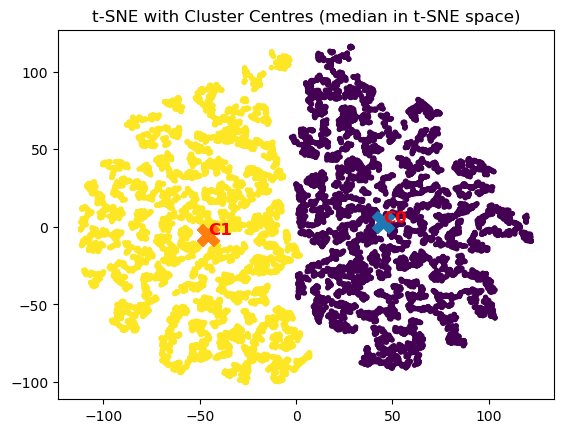

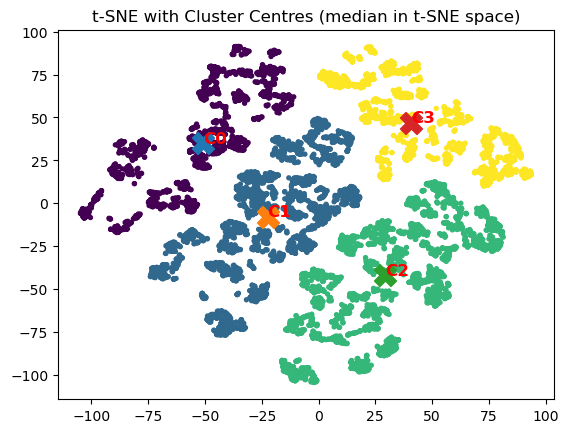

In [63]:
# pre
plotting_clusters(labels_pre, tsne_pre)

#post
plotting_clusters(labels_post, tsne_post)

## Single coure level analysis (surveys with 10+ response)

In [64]:
# filter based on the number of the response

# filter function
def survey_filter(df):
    IDfilter_list = []
    courses_uniq = df['Course'].unique()
    for course in courses_uniq:
        df_perCourse = df[df['Course'] == course]
        if len(df_perCourse) >= 100:
            id_course = df_perCourse['courseID'].iloc[0]
            IDfilter_list.append(id_course)
    return IDfilter_list
        


In [65]:
# courseID for the target courses
pre_ids = survey_filter(agg_pre)
print(len(pre_ids))

post_ids = survey_filter(agg_post)
print(len(post_ids))

26
14


In [66]:
agg_pre.head()


,courseID,Course,Q01_Question 1->I’m interested in the course topic.,Q01_Question 1->I want to earn a certificate (e.g. Record of Participation / Achievement).,Q01_Question 1->It’s part of my university studies (e.g. a required or elective course).,Q01_Question 1->I want to deepen my knowledge for professional development.,Q01_Question 1->I’m pursuing a higher professional qualification or career change.,Q01_Question 1->I already have prior knowledge and am looking to refresh or expand it.,Q01_Question 1->I want to use the course materials in my own teaching.,Q01_Question 1->Other,...,Q06_Question 6->Information Technology or Media,"Q06_Question 6->Finance, Insurance, or Real Estate",Q06_Question 6->Healthcare or Social Services,"Q06_Question 6->Education, Research, or Childcare",Q06_Question 6->Public Administration or Government,Q06_Question 6->Hospitality or Tourism,Q06_Question 6->Other Services,Q06_Question 6->Other / None of the above,Q06_Question 6->I’d rather not answer,Q02
0,106,Einführung in die KI,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN
1,106,Einführung in die KI,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,106,Einführung in die KI,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,106,Einführung in die KI,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,106,Einführung in die KI,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN


In [69]:
# function for analyse each item
# slice base on the survey type and item number (e.g., Q01 --> set of Q1 questions)

def analyser(df, courseID, question = 'Q01', survey_type = 'pre'):
    df_course = df[df['courseID'] == courseID]
    pattern = question
    cols = df_course.columns
    # select cols based on the regex
    cols_selected= [s for s in cols if re.search(pattern, s)]
    # check the aggreated frequency
    df_course = df_course[cols_selected]
    count_freq = freq_pct_calculator(df_course)
    # plotting 
    plotting_freq_pct(df = count_freq, title = f"Percentage of Response of {question} ({survey_type})")
    return count_freq    


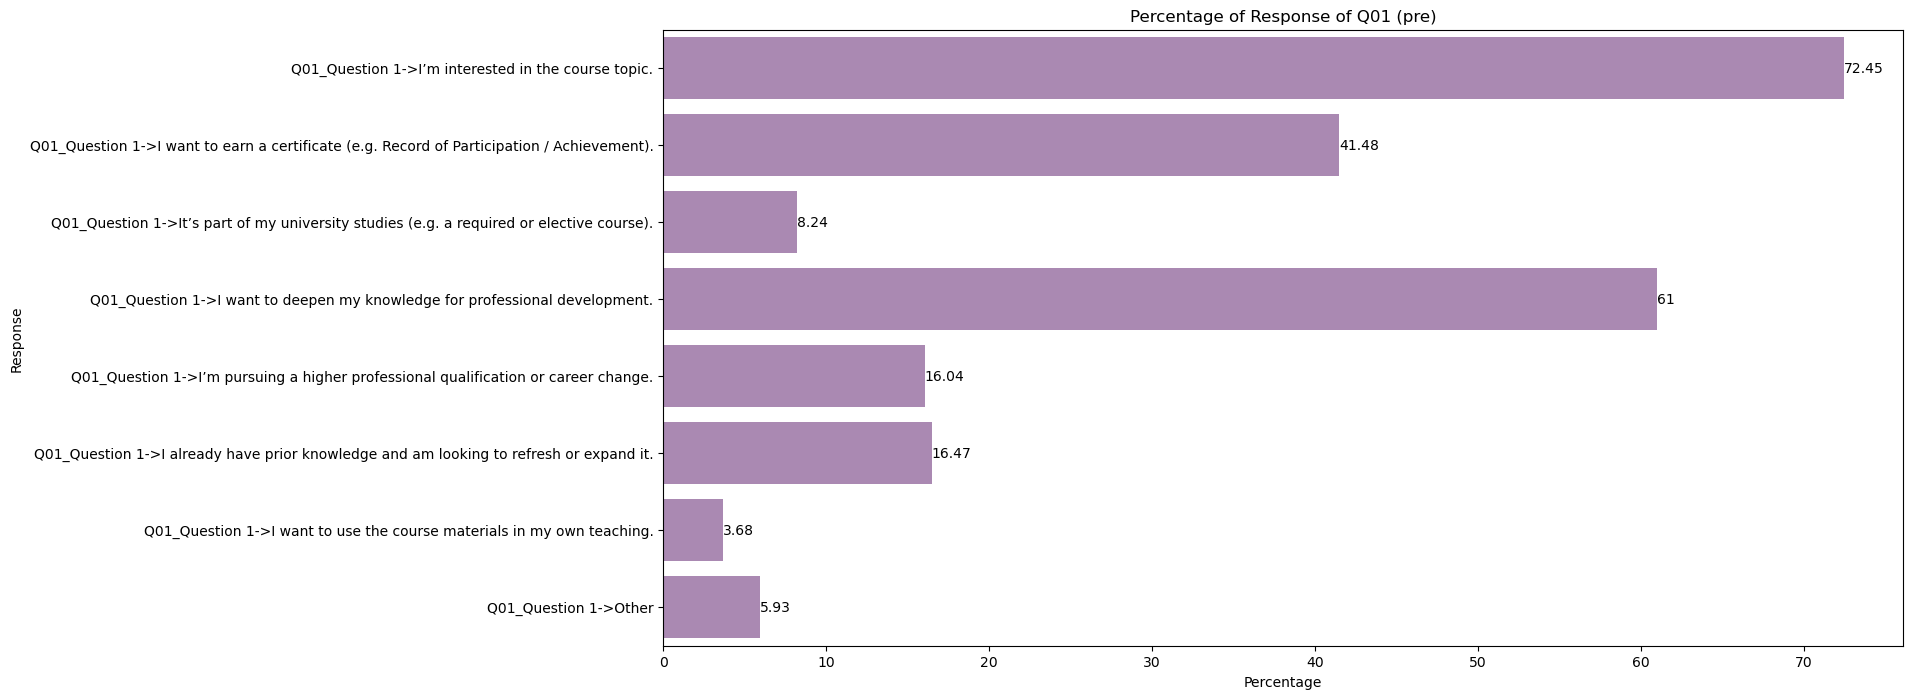

,Options,Percentage %
0,Q01_Question 1->I’m interested in the course t...,72.45
1,Q01_Question 1->I want to earn a certificate (...,41.48
2,Q01_Question 1->It’s part of my university stu...,8.24
3,Q01_Question 1->I want to deepen my knowledge ...,61.00
4,Q01_Question 1->I’m pursuing a higher professi...,16.04
5,Q01_Question 1->I already have prior knowledge...,16.47
6,Q01_Question 1->I want to use the course mater...,3.68
7,Q01_Question 1->Other,5.93


In [70]:
# testing case
pre_Q1_test = analyser(agg_pre, courseID = 106, question = 'Q01', survey_type = 'pre')

pre_Q1_test

In [ ]:
#agg_pre.head()
#agg_post.isnull().sum()